author: Justin Sankey, Johanna Ganglbauer

**description**: Takes raw liquid chromatography mass spectroscopy (LCMS) data (exported table from SCIEX Analyst Software), converts mass (ng/sample) to concentration, evaluates QAQC criteria: (i) retention time shifts, (ii) method detection limits, (iii) recovery rates or standard response deviations, and (iv) ion abundance ratio deviations.
Generates plots, writes results to excel, and creates long format table (.csv) for data publications.

**What is implemented compared to previous version**:
*   Reads in idl file generated from calculate_idl routine directly -> IDLs for MS/MS and HRMS channels respectively
*   assigns right HRMS channel to confirmation compounds
*   sorts compounds according to predefined order

**what needs to be implemented**:
*   JB: choose output name according to name of first data file
*   JG: concentration ratios instead of ion abundance ratios
*   JG: automated checks for QSC0 and CS6
*   include 10 % rule somewhere somehow
*   JG: include EPA thresholds for recoveries
*   JB: once enough data has been collected calculate 'default MDLs'
*   **feel free to add your thoughts!**

**contact/help/complaints:** johanna.ganglbauer@uri.edu

# Loading packages, Settings
The block below will load all python packages needed for the following analysis.\
Moreover, it sets the display options to show data tables in your console and suppresses warnings

In [1]:
# import all needed packages
import os
import numpy as np
from openpyxl import load_workbook
from openpyxl.drawing.image import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd

# import functions from utils.py
from utils import (
    read_in_data_files, get_sample_id_and_name, get_hrms_and_msms_compounds, get_hrms_and_msms_standards,
    parse_project_folder_structure, clean_up_data, round_to_n_sigfigs, reassign_tof_nis_to_eis,
    change_worksheet_color, color_fields, get_eis_for_pfas)

# import and suppress warnings
import warnings
warnings.filterwarnings('ignore')

# display settings
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full width of columns

# Change project_folder variable in current code block
Make sure you setup the project folder by following the instructions in the notebook **create_project_folder.ipynb** before you run the current notebook.

Change the variable **project_folder** in the first Code block of the notebook, so that it points to the project folder you created with the notebook **create_project_folder.ipynb**.
You can copy the path of your project folder on windows by right clicking on the folder in your file explorer and choosing the option *Copy as Path*. \
The same works on Mac OS: Control-click or right-click on the folder in Finder. Press the Option (Alt) key. Choose *Copy [foldername] as Pathname*.

To indicate the project folder put an **r** in front of your file path. This helps python interpret backslashes in your filepaths.\
Here is an example: r'C:\Users\johanna.ganglbauer\archive\code\PFAS-SCIEX-Data-Processing-Analysis\test'

In [2]:
### INPUT FILEPATHS
project_folder = r'test'  # path to the project folder

# The following tests if the project folder has the desired structure and throws errors if not.
parse_project_folder_structure(project_folder)

# EXPERT AREA for Inputs
Usually you can leave the Code block below unchanged.\
Provides advanced simulation paramters used by the Code. 

In [3]:
# idl default value
idl_unknown = 1e-3

# used to identify internal standards from column "Component Name" - usually you do not have to change it
standard_identifiers = 'EIS|NIS|IDA|IPS|13C|d-|d3-|d5-|18O'

# limits for concentration values in plots
concentration_limit_plot = 0.8

# limits for recovery rate values in plots
recovery_limit_plot = 6e2

### OUTPUT FILLEPATHS
# processed data output excel/csv file path - without .xlsx/.csv ending
processed_filepath_csv = os.path.join(project_folder, 'processed_data', 'output.csv')
processed_filepath_xlsx = os.path.join(project_folder, 'processed_data', 'output.xlsx')

# directory to save plots to
plot_directory = os.path.join(project_folder, 'processed_data', 'plots')

# Read in simulation parameters
(i) simulation parameters from simulation_parameters.csv \
(ii) sample_parameters from sample_parameters.csv. In addition, the predominant unit used within the data is extracted and the average sample size. Both will be used for the normalization of MDLs at a later stage\
(iii) thresholds for recovery rates or internal standard response deviation (short chain PFAS), as well as thresholds for retention time differences and ion abundance ratio deviations.

All input parameters are written to the output excel sheet.

In [4]:
# read csv file as data frame
simulation_parameters = pd.read_csv(os.path.join(project_folder, 'code_parameters', 'simulation_parameters.csv'), index_col=[0])

# extract all simulation parameters from csv file, parse them and save them to variables used in the codeblocks to follow.
eis_identifier = simulation_parameters.loc['EIS identifier', 'Parameter Value']
nis_identifier: str = simulation_parameters.loc['NIS identifier', 'Parameter Value']
hrms_identifier: str = simulation_parameters.loc['HRMS identifier', 'Parameter Value']
hrms_identifier_string_number: int = len(hrms_identifier)
calibration_midpoint_identifier: str = simulation_parameters.loc['calibration midpoint identifier', 'Parameter Value']
calibration_reference: str = simulation_parameters.loc['calibration reference', 'Parameter Value']
standard_concentration: str = simulation_parameters.loc['standard concentration', 'Parameter Value']
method_identifier: str = simulation_parameters.loc['method identifier', 'Parameter Value']
recovery_rate_type: str = simulation_parameters.loc['method to calculate recoveries', 'Parameter Value']

In [5]:
if os.path.exists(os.path.join('lab_parameters', str(method_identifier) + '_idl.csv')):
    idl_filepath = os.path.join('lab_parameters', str(method_identifier) + '_idl.csv')
else:
    raise NameError(
        f'No IDL file found for method identifier {method_identifier}. Please check if the file lab_parameters/{method_identifier}_idl.csv exists.'
        'You either have to reset the method identifier in your simulation_parameters.csv, or run calculate_idl.py to generate a new IDL file.'
        )

In [6]:
# read in sample input data
sample_input_data = pd.read_csv(os.path.join(project_folder, 'code_parameters', 'sample_parameters.csv'), index_col=[0])

# save relation of index and sample name in publication
sample_number_mapper_sample_name = sample_input_data['alternative name (used in results)'].to_dict()
# save relation of index and unit in publication
sample_number_mapper_sample_unit = sample_input_data['unit (e.g. g/mL/sample)'].to_dict()

# get and save dominant unit
sample_dominant_unit = sample_input_data.loc[~sample_input_data['used for mdl calculation'],'unit (e.g. g/mL/sample)'].value_counts().nlargest(1).index[0]
# get and save average sample size
sample_average_size = sample_input_data.loc[(
    (~sample_input_data['used for mdl calculation']) & (sample_input_data['unit (e.g. g/mL/sample)'] == sample_dominant_unit)
    ),'volume/weight/number of samples'].mean()

if standard_concentration == 'spiked_per_ml_sample' and sample_dominant_unit != 'g':
    raise ValueError("""
    If you use the 'spiked_per_ml_sample' standard concentration, you have to use 'g' as sample unit.
    """)

In [7]:
# read in recovery threshold limits and save them as dictionary
recovery_or_standard_response_thresholds = pd.read_csv(os.path.join(project_folder, 'code_parameters', 'eis_parameters.csv'), index_col=[0])
recovery_or_standard_response_thresholds_dict = recovery_or_standard_response_thresholds.to_dict()

# read in allowed retention time differences and ion abundance ratios and save them as dictionary
rtd_and_iar_thresholds_channel_selection = pd.read_csv(os.path.join(project_folder, 'code_parameters', 'compound_parameters.csv'), index_col=[0])
rtd_iard_channel_dict = rtd_and_iar_thresholds_channel_selection.to_dict()

In [8]:
# write input parameters to excel
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl') as writer:
    sample_input_data.to_excel(writer, sheet_name='Sample Input Data')
    recovery_or_standard_response_thresholds.to_excel(writer, sheet_name='RR or SRD Thresholds')
    rtd_and_iar_thresholds_channel_selection.to_excel(writer, sheet_name='RTD and IAR Thresholds')
    simulation_parameters.to_excel(writer, sheet_name='Simulation Parameters')

# Read in data and clean up 
The following Code block reads in all raw data files and cleans up data. Uses functions read_in_data_files(), get_sample_id_and_name(), and clean_up_data() from utils.py.\
Makes sure the component IPS-13C2_PFOA, and 13C2_PFOA_TOF MS is not used as non extracted standard, replaces it with IPS-13C4_PFOA, and 13C4_PFOA_TOF MS, respectively - relevant for 'older data' originating from 2024, hopefully obsolete soon.

In [9]:
# calls function to read in data files and returns a data frame with all data
data = read_in_data_files(project_folder=project_folder)

# extract sample names and compound names from raw data
sample_list = get_sample_id_and_name(data)

# save relation of sample indices to original sample names
sample_index_mapper_sample_name_orig = dict(zip(
    [int(index) for index in sample_list['Sample Index Core'].dropna().tolist() + sample_list['Sample Index Extended'].dropna().tolist()], 
    sample_list['Sample Name Core'].dropna().tolist() + sample_list['Sample Name Extended'].dropna().tolist(),
    ))

# save relation of sample indices to sample numbers
sample_index_mapper_sample_number = dict(zip(
    [int(index) for index in sample_list['Sample Index Core'].dropna().tolist() + sample_list['Sample Index Extended'].dropna().tolist()], 
    sample_list.loc[~sample_list['Sample Index Core'].isna(),:].index.tolist() + sample_list.loc[~sample_list['Sample Index Extended'].isna(),:].index.tolist(),
    ))

# calls function to get complete list of samples
data = clean_up_data(data=data, sample_list=sample_list)

# get the assignment of NIS for HRMS channel EIS right
data = reassign_tof_nis_to_eis(data=data)

# get compounds dataframe and delete 'useless compounds'
compounds, delete_compounds, available_compounds = get_hrms_and_msms_compounds(
    data=data, sample_list=sample_list, hrms_identifier=hrms_identifier, standard_identifiers=standard_identifiers
    )

# delete detected compounds accordingly. 
# Usualy HRMS channels from the core method have to be deleted, because they also occur in the extended method, where they are integrated with more care.
if not delete_compounds.empty:  # check if data frame is empty
    for method in delete_compounds['from method'].unique():  # loop over 'core' method and 'extended method'
        # get all sample indices from relevant method
        if method == 'core':
            indices = [int(index) for index in sample_list['Sample Index Core'].dropna().tolist()]
        elif method == 'extended':
            indices = [int(index) for index in sample_list['Sample Index Extended'].dropna().tolist()]
        # loop over compounds to be deleted within the method and delete them accordingly
        for compound in delete_compounds.loc[delete_compounds['from method'] == method, 'Compound Name'].tolist():
            data = data.loc[~(
                (data['Component Name'] == compound) & (data['Sample Index'].isin(indices))
            ), :]

# extract list of standard names in right order from raw data
standards, delete_standards = get_hrms_and_msms_standards(
    data=data, sample_list=sample_list, hrms_identifier=hrms_identifier, standard_identifiers=standard_identifiers,
    eis_identifier=eis_identifier, nis_identifier=nis_identifier
    )

# delete standards if necesary
if not delete_standards.empty:
    data = data.loc[~data['Component Name'].isin(delete_standards['Compound Name'].tolist()), :]

# Delete all '13C2_PFOA_TOF MS' channel rows if they are in the data set (just to be sure)
data = data.loc[~data['Component Name'].isin(['13C2_PFOA_TOF MS', 'IPS-13C2_PFOA', '13C2_PFOA']), :]

# Replace 'IPS-13C2_PFOA' values: optional, only when component name occurs
for (compound, replacement_compound) in zip(['IPS-13C2_PFOA', '13C2_PFOA_TOF MS'],['IPS-13C4_PFOA', '13C4_PFOA_TOF MS']):
    if any(data['Component Name'].isin([replacement_compound])):
        data['Component Group Name'] = data['Component Group Name'].replace(compound, replacement_compound)

        # Find rows where 'Component Group Name' is 'IPS-13C4_PFOA' (after replacement)
        mask = data['Component Group Name'] == replacement_compound

        # Iterate through each of these rows and replace area in column
        for idx, row in data[mask].iterrows():
            sample_name = row['Sample Name']

            # Find the corresponding row with 'Component Name' == 'IPS-13C4_PFOA' and the same 'Sample Name'
            matching_row = data[(data['Component Name'] == replacement_compound) & (data['Sample Name'] == sample_name)]

            if not matching_row.empty:
                # Update the retention time of the internal standard with the value from 'IS Retention Time' in the matching row
                data.at[idx, 'IS Retention Time'] = matching_row['IS Retention Time'].values[0]

# saves list of compound names, sorts compounds according to predefined order, and aranges final output depending on selected channel (MSMS/HRMS/None)
 - eis_compounds_msms: list of mass labeled extracted internal standards (EIS) from the MS/MS channel with the compound order preserved from the order in the raw data,
- eis_compounds_hrms: list of mass labeled extracted internal standards (EIS) from the HRMS channel with the compound order preserved from the order in the raw data,
- nis_compounds_msms: list of mass labeled non-extracted internal standards (NIS) from the MS/MS channel with the compound order preserved from the order in the raw data,
- nis_compounds_hrms: list of mass labeled non-extracted internal standards (NIS) from the HRMS channel with the compound order preserved from the order in the raw data,
- pfas_compounds_msms: list of pfas target analytes from the MS/MS channel, with the compounds sorted according to predefined order,
- pfas_compounds_hrms: list of pfas target analytes from the HRMS channel, with the compounds sorted according to  predefined order,

In [10]:
# get list of sorted IDA and IPS names from msms channel\n",
eis_standards = standards.loc[standards['Standard Type'] == eis_identifier, :]
nis_standards = standards.loc[standards['Standard Type'] == nis_identifier, :]
eis_compounds_msms = eis_standards['MSMS Standard Name'].dropna().tolist()
eis_compounds_hrms = eis_standards['HRMS Standard Name'].dropna().tolist()
nis_compounds_msms = nis_standards['MSMS Standard Name'].dropna().tolist()
nis_compounds_hrms = nis_standards['HRMS Standard Name'].dropna().tolist()

# read in right order of compounds from lab_parameters/compound_order.csv
compounds_sorted_predefined = pd.read_csv(os.path.join('lab_parameters', 'compound_order.csv'), usecols=[0,1])
compounds_sorted_hrms_predefined = [compound + hrms_identifier for compound in compounds_sorted_predefined['Name'].to_list()]

# get rid of np.nan component names when used as index to create tables
pfas_compounds_msms_all = compounds['MSMS Compound Name'].dropna().tolist()
pfas_compounds_hrms_all = compounds['HRMS Compound Name'].dropna().tolist()

# get compounds into predefined order
pfas_compounds_msms = [
    compound for compound in compounds_sorted_predefined['Name'].to_list() if compound in pfas_compounds_msms_all
    ]
pfas_compounds_hrms = [
    compound for compound in compounds_sorted_hrms_predefined if compound in pfas_compounds_hrms_all
    ]

if len(pfas_compounds_msms_all) != len(pfas_compounds_msms) or len(pfas_compounds_hrms_all) < len(pfas_compounds_hrms):
    raise NameError(
        'One of the compounds is not included in the predefined compound order list.'
        'Please check lab_parameters/compound_order.csv and ensure that all compounds are listed there.'
        )

# prepare list of all compounds with MSMS and HRMS accoring to the selected channel for quantification\n",
pfas_compounds_selected = []
for (pfas_compound, channel_selection) in rtd_and_iar_thresholds_channel_selection.iterrows():
    if any(standard_identifier in pfas_compound for standard_identifier in standard_identifiers.split('|')):
        continue
    if channel_selection['Selected channel for quantification [MSMS/HRMS/NONE]'] == 'MSMS':
        if pfas_compound.endswith(hrms_identifier):
            pfas_compound = pfas_compound[:(-1) * hrms_identifier_string_number]
        if pfas_compound in compounds['MSMS Compound Name'].tolist():
            pfas_compounds_selected.append(pfas_compound)
        else:
            raise NameError(f'The compound {pfas_compound} in the MSMS channel is not available in the data set.')
    elif channel_selection['Selected channel for quantification [MSMS/HRMS/NONE]'] == 'HRMS':
        if not pfas_compound.endswith(hrms_identifier):
            pfas_compound = pfas_compound + hrms_identifier
        if pfas_compound in compounds['HRMS Compound Name'].tolist():
            pfas_compounds_selected.append(pfas_compound)
        else:
            raise NameError(f'The compound {pfas_compound} in the HRMS channel is not available in the data set.')
    elif channel_selection['Selected channel for quantification [MSMS/HRMS/NONE]'] == 'NONE':
        continue
    else:
        raise NameError(
            f'The key {channel_selection['Selected channel for quantification [MSMS/HRMS/NONE]']} is not valid.'
            f" Please use 'MSMS', 'HRMS' or 'NONE' as key for the selected channel for quantification in the file 'rt_iar_thresholds_channel_selection.csv'."
            )

# Seperate data in calibration, calibration midpoint and samples
The following code block separates data in calibration data, calibration midpoint data and sample data.\
For calibration data and calibration midpoint data, the simulation parameter **calibration_reference** is used to: \
(1) choose calibration and calibration midpoint data from initial calibration in case the parameter is set to **calibration** \
(2) choose calibration and calibration midpoint data from continous calibration verification (CCV) in case the parameter is set to **ccv**

In addition, errors are returned, in case the chosen reference data is not available, or the parameter is set wrong.

In [11]:
# Split data into sample data, calibration data, and calibration_midpoint data

# get sample data
sample_data = data[(data['Sample Type'] != 'Standard')]

# get calibration data, and calibration midpoint data from internal calibration, throw error if not available
if calibration_reference == 'calibration':
    calibration_data = data[(data['Sample Type'] == 'Standard')]
    # Throw error if calibration data is not available
    if calibration_data.empty:
        raise ImportError(
            "There is no calibration data included in your data sets. Check your raw data files and make sure calibration data is included"
        )
    calibration_reference_data = calibration_data[(calibration_data['Sample ID'].str.contains(calibration_midpoint_identifier))]

# get calibration data and calibration midpoint data from continous calibration verification, throw error if not available
elif calibration_reference == 'ccv':
    calibration_data = sample_data[(
        (sample_data['Sample ID'].str.contains(f'CS0|{calibration_midpoint_identifier}')) & (sample_data['Sample Type'] == 'Unknown')
        )]
    if calibration_data.empty:
        raise ImportError(
            "There is no continuous calibration verification data included in your data sets. Check your raw data files and make sure CCV data is included." + \
            "CCV data contains 'CS0' or the calibration midpoint identifier (set in simulation parameters) in the Sample ID, and has an Unknown Sample Type." + \
            "In case you have not enough CCV data available consider using the calibration as reference. Set your simulation parameter calibration midpoint reference to 'calibration'."
        )
    calibration_reference_data = calibration_data[(calibration_data['Sample ID'].str.contains(calibration_midpoint_identifier))]
else:
    raise NameError(
        "The simulation parameter calibration midpoint reference in your simulation parameters must be either 'calibration' or 'ccv', the code cannot handle other options."
    )

# check for methods separately if calibration data is available
for method_identifier in ['Core', 'Ext']:
    if any(sample_data['Sample Name'].str.endswith(method_identifier)):
        if not any(calibration_data['Sample Name'].str.contains(method_identifier)):
            raise ImportError(
                f"There is no calibration data available for {method_identifier} method."
            )


# Account for dilution factor
Multiply 'Actual Concentration' Column with dilution factor.


In [12]:
for (sample_number, sample_input_row) in sample_input_data.iterrows():
    dilution_factor = sample_input_row['dilution factor']
    sample_data.loc[sample_data['Sample Number'] == sample_number, 'Calculated Concentration'] = \
        sample_data.loc[sample_data['Sample Number'] == sample_number, 'Calculated Concentration'] * dilution_factor

# Create tables for detected pfas masses
Pivot tables are created to construct and export tables containing the 'Calculated Concentration' information from the raw data.
The 'Calculated Concentration' information corresponds to ng of PFAS detected in the sample, or ng of PFAS per g tissue for the procedure at pharmacy with variable EIS standard spiked.

Tables for both channels MS/MS and HRMS are exported to excel.

In [13]:
pfas_mass = sample_data.pivot_table(
    index=('Sample Number'), columns='Component Name', values='Calculated Concentration', dropna=False,
)
pfas_mass.rename(index=sample_number_mapper_sample_name , inplace=True)
# sort MS/MS compounds according to lab_parameter/compound_order.csv
pfas_mass_msms = pfas_mass[pfas_compounds_msms]
# sort HRMS compounds according to lab_parameter/compound_order.csv
pfas_mass_hrms = pfas_mass[pfas_compounds_hrms]

# write initial concentrations to excel file
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
    if standard_concentration == 'spiked_per_sample':
        pfas_mass_msms.to_excel(writer, sheet_name='MSMS Mass (ng per Sample)')
        pfas_mass_hrms.to_excel(writer, sheet_name='HRMS Mass (ng per Sample)')
    elif standard_concentration == 'spiked_per_ml_sample':
        pfas_mass_msms.to_excel(writer, sheet_name='MSMS Mass (ng per mL)')
        pfas_mass_hrms.to_excel(writer, sheet_name='HRMS Mass (ng per mL)')
    
if standard_concentration == 'spiked_per_sample':
    change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=['MSMS Mass (ng per Sample)', 'HRMS Mass (ng per Sample)'], color='0080FF')
elif standard_concentration == 'spiked_per_ml_sample':
    change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=['MSMS Mass (ng per mL)', 'HRMS Mass (ng per mL)'], color='0080FF')

# Visual Sanity Check 1:
The peak areas of non-extracted internal standards (NIS) are shown within the calibration data (internal calibration or continous calibration verification, depending on your choice in simulation_parameter.csv), and within the samples themselves. \
Within calibration you usually add 4 ng internal standards to 1 mL calibration samples. \
In most of the cases you add 4 ng internal standard to your 0.5 mL samples. \
Therefor, the peak areas of the NIS in your samples (right) should be double of the peak areas of the corresponding NIS in calibration data (left).

**Doublecheck that the information you provided in the "Actual Concentration" column is correct! This will affect your recovery rates. Usually you add 4 ng/(0.5 mL sample). Check the title of the right boxplot**.

In the following code there are no QAQC criteria, which flag samples with highly deviating NIS peak areas, it is your responsibility to check the ranges. It will affect the recovery rates, so it is a good idea to make sure that the areas are in comparable ranges, or you can explain why they are not.

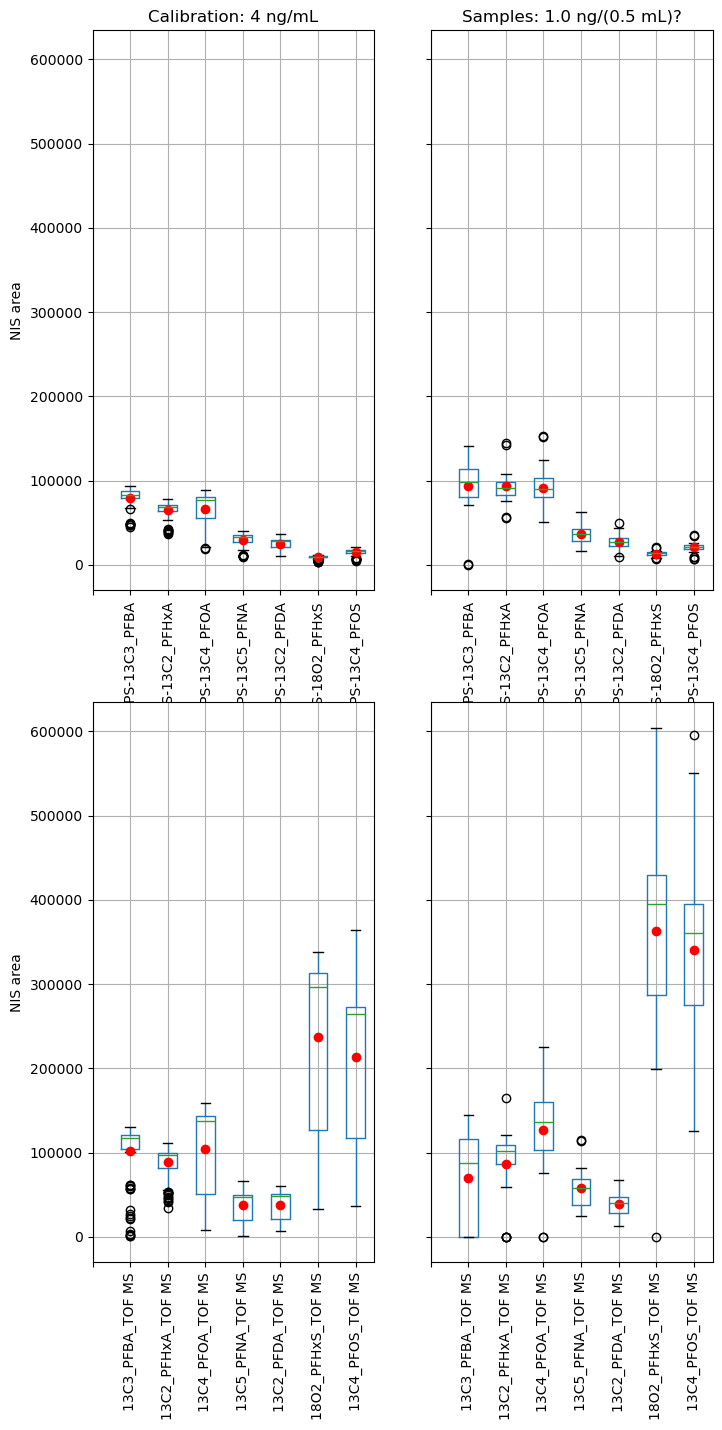

In [14]:
if len(nis_compounds_msms) > 0 or len(nis_compounds_hrms) > 0:   
    # Extract NIS MSMS and HRMS data from calibration and sample data
    calibration_data_nis_msms = calibration_data[calibration_data['Component Name'].isin(nis_compounds_msms)]
    calibration_data_nis_hrms = calibration_data[calibration_data['Component Name'].isin(nis_compounds_hrms)]
    sample_data_nis_msms = sample_data[sample_data['Component Name'].isin(nis_compounds_msms)]
    sample_data_nis_hrms = sample_data[sample_data['Component Name'].isin(nis_compounds_hrms)]

    # evaluate mean per component for MSMS and HRMS for calibration and sample data
    calibration_nis_msms_averages = calibration_data_nis_msms.groupby('Component Name')['Area'].mean()
    calibration_nis_tof_averages = calibration_data_nis_hrms.groupby('Component Name')['Area'].mean()
    samples_nis_msms_averages = sample_data_nis_msms.groupby('Component Name')['Area'].mean()
    samples_nis_tof_averages = sample_data_nis_hrms.groupby('Component Name')['Area'].mean()

    # extract groups for MSMS and HRMS for calibration and sample data
    calibration_nis_msms_grouped = calibration_data_nis_msms.groupby('Component Name', sort=False)
    calibration_nis_tof_grouped = calibration_data_nis_hrms.groupby('Component Name', sort=False)
    samples_nis_msms_grouped = sample_data_nis_msms.groupby('Component Name', sort=False)
    samples_nis_tof_grouped = sample_data_nis_hrms.groupby('Component Name', sort=False)

    # evaluate IPS concentration in quantification
    nis_concentration = sample_data_nis_msms['Actual Concentration'].mean()

    # create plot for comparison
    # initialize figure with subplots
    image_path = os.path.join(plot_directory, 'ips_areas.png')
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 16), sharey=True)
    # boxplt plot NIS areas + averages for MSMS data [0, x] for calibration [0,0] and samples [0,1]
    calibration_nis_msms_grouped.boxplot(column='Area', ax=ax[0, 0], subplots=False)
    ax[0, 0].plot([np.nan] + calibration_nis_msms_averages[nis_compounds_msms].to_list(), color='red', linestyle='', marker="o", label='calibration average')
    samples_nis_msms_grouped.boxplot(column='Area', ax=ax[0, 1], subplots=False)
    ax[0, 1].plot([np.nan] + samples_nis_msms_averages[nis_compounds_msms].to_list(), color='red', linestyle='', marker="o", label='quantification average')
    # boxplt plot NIS areas + averages for HRMS data [1, x] for calibration [1,0] and samples [1,1]
    calibration_nis_tof_grouped.boxplot(column='Area', ax=ax[1, 0], subplots=False)
    ax[1, 0].plot([np.nan] + calibration_nis_tof_averages[nis_compounds_hrms].to_list(), color='red', linestyle='', marker="o", label='calibration average')
    samples_nis_tof_grouped.boxplot(column='Area', ax=ax[1, 1], subplots=False)
    ax[1, 1].plot([np.nan] + samples_nis_tof_averages[nis_compounds_hrms].to_list(), color='red', linestyle='', marker="o", label='quantification average')
    # no figure title
    fig.suptitle('')
    # set axis descriptions
    ax[0, 0].set_title('Calibration: 4 ng/mL')
    ax[0, 1].set_title(f'Samples: {round(nis_concentration, 0)} ng/(0.5 mL)?')
    ax[0, 0].set_xticks(
        ticks=range(len(calibration_nis_msms_averages) + 1),
        labels=[''] + nis_compounds_msms, rotation=90
        )
    ax[0, 1].set_xticks(
        ticks=range(len(samples_nis_msms_averages) + 1),
        labels=[''] + nis_compounds_msms, rotation=90
        )
    ax[0, 0].set_ylabel('NIS area')
    ax[1, 0].set_xticks(
        ticks=range(len(calibration_nis_tof_averages) + 1),
        labels=[''] + nis_compounds_hrms, rotation=90
        )
    ax[1, 1].set_xticks(
        ticks=range(len(samples_nis_tof_averages) + 1),
        labels=[''] + nis_compounds_hrms, rotation=90
        )
    ax[1, 0].set_ylabel('NIS area')
    [[this_ax.set_xlabel('') for this_ax in ax_row] for ax_row in ax]
    # save figure and show
    plt.savefig(image_path, bbox_inches='tight')
    plt.show()

    # save NIS area comparison plot to excel file
    workbook = load_workbook(processed_filepath_xlsx)
    plot_sheet = workbook.create_sheet('NIS Areas')

    img = Image(os.path.join(plot_directory, 'ips_areas.png'))

    cell_position = plot_sheet.cell(row=1, column=1).coordinate
    plot_sheet.add_image(img, cell_position)
    plot_sheet['N1'] = """
    The peak areas of non-extracted internal standards (NIS) are shown within the calibration data 
    (internal calibration or continous calibration verification, depending on your choice in simulation_parameter.csv)
    on the left, and within the samples themselves on the right."""
    plot_sheet['N2'] = "The top row is for the MSMS channel, while the bottom row represents the HRMS channel."
    plot_sheet['N3'] = "Within calibration you usually add 4 ng internal standards to 1 mL calibration samples."
    plot_sheet['N4'] = "In most of the cases you add 4 ng internal standard to your 0.5 mL samples."
    plot_sheet['N5'] = "Therefor, the peak areas of the NIS in your samples (right) should be double of the peak areas of the corresponding NIS in calibration data (left) for each NIS."

    workbook.save(processed_filepath_xlsx)
else:
    print("No NIS found in raw data. Probably you are working with short-chain-PFAS, otherwise make sure your NIS-identifier is set to either IPS or EIS (depending on Sciex Method version).")

In the following code block the data (calibration not included) is separated in the data junk used for mdl calculation,
and the remaining data (where the PFAS are quantified).

In [15]:
indices_for_mdl_evaluation = sample_input_data[sample_input_data['used for mdl calculation']].index

if len(indices_for_mdl_evaluation) == 0:
    mdl_only = None
    print(f'Be careful, no samples have been collected for the MDL calculation.')
else:
    mdl_only = sample_data[sample_data['Sample Number'].isin(indices_for_mdl_evaluation)]

Be careful, no samples have been collected for the MDL calculation.


# QAQC Criterion 1: Retention Time Shift (RTS)
Compares retention time of PFAS compound with retention time of corresponding extracted internal standard (EIS) for each sample.\
For Compounds with the molecular structure of the mass labeled internal standard being different than the molecular structure of the compound itself, the average difference of the retention time of the related extracted internal standard is calculated from calibration midpoint samples.

Depending on your choice in simulation_parameters.csv your calibration midpoint from continous calibration verification (CCV) is selectes as reference, or from initial calibration, respectively.

The first Code Block below evaluates average retention time differences between pfas target compound and corresponding internal standard from the selected calibration midpoint. Is set to zero if chemical structure of analytical standard and corresponding internal standard is the same. Differences (or deltas) are saved to excel sheet 'RT shift'.

Second Code Block below provides functions to 'highlight' cells in excel red, based on boolean mask, as well as a function to rename samples (rows) in excel tables.

Third Code Block below calculates retention time differences (or deltas) between analytical standard and corresponding internal standard and compares to threshold rt_threshold, which is defined in the simulation parameters.

In [16]:
# evaluate retention time of reference (=mid point from continous calibration verification or calibration)
calibration_reference_rt = calibration_reference_data.loc[
    :, ['Sample Name', 'Component Name', 'Retention Time', 'IS Name']
    ]

# calculate mean retention time from selected reference point
calibration_reference_rt_group = calibration_reference_rt.groupby('Component Name')['Retention Time'].mean()

# initial dataframe which saves acceptable retention time shifts from selected reference point 
rt_shift_df = pd.DataFrame({"RT":[], "IS RT":[], 'RT diff':[]})

# loop over all compounds of selected reference midpoint
for indexed_compound_name, retention_time in calibration_reference_rt_group.items():
    # skip internal standards
    if any(substring in indexed_compound_name for substring in [eis_identifier, nis_identifier] + standard_identifiers.split('|')):
        continue
    # get name of corresponding internal standard (IDA)
    is_name = calibration_reference_rt.loc[calibration_reference_rt['Component Name']==indexed_compound_name, 'IS Name'].to_list()[0]
    # get retention time of corresponding inernal standard (IDA) in calibration mid point
    is_rt = calibration_reference_rt_group[is_name]
    # if molecular structure (and naming) of compound and corresponding internal standard 
    # are the same, no additional delta in retention time is allowed
    if indexed_compound_name in is_name:
        rt_shift_df.loc[indexed_compound_name, :] = [retention_time, is_rt, 0]
    # if molecular structure (and naming) of compound and corresponding internal standard
    # are not the same, save addition delta in retention time from calibration midpoint
    else:
        rt_shift_df.loc[indexed_compound_name, :] = [retention_time, is_rt, round_to_n_sigfigs(x=retention_time - is_rt,n=4)]
        # use retention time of target compound in the calibration midpoint as reference and save it to the column 'IS Retention Time'
        sample_data.loc[sample_data['Component Name']==indexed_compound_name, 'IS Retention Time'] = \
            sample_data.loc[sample_data['Component Name']==indexed_compound_name, 'IS Retention Time'] - is_rt + retention_time

# extract tof data and put HRMS information from compound name to column header
rt_shift_hrms = rt_shift_df.loc[pfas_compounds_hrms]  # extract in right chemical order
rt_shift_hrms.index = [item[0] for item in rt_shift_hrms.index.str.split('_')]  # reindex with msms names
rt_shift_hrms.columns = [elem + ' HRMS' for elem in rt_shift_hrms.columns]  # add 'HRMS' to column names

rt_shift_msms = rt_shift_df.loc[pfas_compounds_msms]
rt_shift_msms.columns = [elem + ' MS/MS' for elem in rt_shift_msms.columns]  # add 'MS/MS' to column names

# merge MSMS data with HRMS data and save it to data frame rt_shift_excel
rt_shift_excel = rt_shift_msms.join(rt_shift_hrms, how="outer")
rt_shift_excel = rt_shift_excel.loc[
    [compound_index for compound_index in compounds_sorted_predefined['Name'].to_list() if compound_index in rt_shift_excel.index]
]

# write sample input data and retention time shifts to excel
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
    rt_shift_excel.to_excel(writer, sheet_name='RT Differences')

In [17]:
# function to color excel according to threshold values / mask
def highlight(data: pd.DataFrame, flag: pd.DataFrame, color:str) -> None:
    '''Sets all data elements to red background, when flag is True. '''
    if data.ndim == 1:  # Series from .apply(axis=0) or axis=1
        return ['background-color: red' if v else '' for v in flag]
    else:  # from .apply(axis=None)
        return pd.DataFrame(np.where(flag, 'background-color: ' + color, ''),
                            index=data.index, columns=data.columns)

# function to replace sample names in excel sheet accordingly
def reindex_in_excel(
        filename: str, sheetname: str, number_name_mapper: dict=sample_number_mapper_sample_name,
        ) -> None:
    """Function to rename index columns in excel."""
    # load excel file
    workbook = load_workbook(filename=filename)
    # open workbook
    sheet = workbook.active
    # get right sheet
    sheet = workbook[sheetname]
    # read in index column
    sample_numbers = [column.value for column in sheet['A']]
  
    # change index column values
    if sample_numbers[0] == 'Sample Number':
        for (row_index, sample_number) in enumerate(sample_numbers[1:]):
            sheet.cell(row=row_index + 2, column=1).value = number_name_mapper[sample_number]
    
    #save the file
    workbook.save(filename=filename)
    workbook.close()

In [18]:
# initialize new retention_time_data frame and select columns
selected_columns = [
    'Sample Name', 'Sample Number', 'Component Name', 'Retention Time', 'IS Retention Time'
]
retention_time_data = sample_data[selected_columns]

# select only channel names of precursor masses (confirmation) and fragmented masses (quantification) \ get rid of standard compounds
retention_time_data = retention_time_data[retention_time_data['Component Name'].isin(pfas_compounds_msms + pfas_compounds_hrms)]

# calculate deviation from retention time of PFAS component and related internal injection standard (IDA)
retention_time_data['Delta Retention Time IS'] = \
    (retention_time_data['Retention Time'] - retention_time_data['IS Retention Time']).apply(lambda x: round_to_n_sigfigs(x=x, n=4))

# initialize new column RTD indicating the limits
retention_time_data['RTD'] = False

# loop over rows of retention_time_data
for (indexed_compound_name, row) in retention_time_data.iterrows():
    # get accepted retention time difference from compound name
    compound_name = row['Component Name']
    # distinguish between HRMS channel and MSMS channel
    if compound_name in rtd_and_iar_thresholds_channel_selection.index.tolist():
         rt_threshold = rtd_iard_channel_dict['accepted retention time difference [min]'][compound_name]
    else:
        if hrms_identifier in compound_name:
            rt_threshold = rtd_iard_channel_dict['accepted retention time difference [min]'][compound_name[:(-1) * hrms_identifier_string_number]]
        else:
            raise NameError(
                f"The compound {compound_name} is not available in the dictionary of accepted retention time differences."
            )
    
    # check if concentration is below detection limit
    if row['Delta Retention Time IS'] < -rt_threshold or row['Delta Retention Time IS'] > rt_threshold:
        retention_time_data.loc[indexed_compound_name, 'RTD'] = True  # flag True if above limit

nan_flag = retention_time_data['Delta Retention Time IS'].isnull()  # save mask of NaN values
retention_time_data.loc[nan_flag, 'RTD'] = np.nan  # set mask values of nan retention time values to np.nan

for (compound_lists, sheet_name) in zip([pfas_compounds_msms, pfas_compounds_hrms], ['MSMS Delta RT in min', 'HRMS Delta RT in min']):
    # Put retention time data in pivot tables
    retention_time_is = retention_time_data.pivot_table(
        index=('Sample Number'), columns='Component Name', values='Delta Retention Time IS', dropna=False,
    )[compound_lists]
    retention_time_is_flag = retention_time_data.pivot_table(
        index=('Sample Number'), columns='Component Name', values='RTD', dropna=False,
    )[compound_lists]

    # Write to excel file
    with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
        retention_time_is.to_excel(writer, sheet_name=sheet_name)

    # color values based on flags
    color_fields(filepath=processed_filepath_xlsx, sheetname=sheet_name, rtd=retention_time_is_flag.fillna(value=False))

    # Use "publication" sample names in final table
    reindex_in_excel(filename=processed_filepath_xlsx, sheetname=sheet_name,)

change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=['RT Differences', 'MSMS Delta RT in min', 'HRMS Delta RT in min'], color='FF0000')

# Method Detection Limits
The following block computes method detection limits (MDL) based on average and standard deviation ($\sigma$) of PFAS concentrations in selected samples (process blanks, etc.). \
The code reads in instrument detection limits (IDL) for the PFAS compounds. For some compounds the IDL may not be included in the input files, in that case the default value is used. \
Before the MDL calculation, **all concentrations below the IDL are replaced with the IDL** in order to ensure that MDLs are never lower than IDLs, and that the standard deviation is low in case of multiple concentrations detected below IDL.\
In case no concentrations could be detected at all, the IDL is used as MDL.

Within the Code the following definition of method detection limits is considered:\
$MDL_{PFAS} = average_{PFAS} + 3 \cdot \sigma_{PFAS}$

# Visual Sanity Check 2
The range of concentrations of selected blank samples for MDL calculations, IDL, and final MDL are depicted in the figure below. Outliers are shown and flagged. If the MDL for a certain PFAS compound is unreasonably high, you should not report/not trust the results for the corresponding compound and troubleshoot for contamination.

# Quality Control Criterion 2:
A new column 'Below Detection Limit (BDL)' is introduced, which indicates all 'Calculated Concentration' Values of PFAS quantification below the determined detection limits. These samples will be flagged as 'BDL' in the final concentration tables.

In [19]:
# Load idl values from idl input file
idl_data = pd.read_csv(idl_filepath, index_col=0, low_memory=False)

# Initialize empty dataframe with IDL, relevant data for MDL calculation and MDL
# considering both channels MS/MS and HRMS
na_list = [np.nan] * len(available_compounds)
if standard_concentration == 'spiked_per_sample':
    mdl = pd.DataFrame({
        'IDL MS/MS': na_list, 'Mean Concentration MS/MS': na_list, 'Mean Concentration IDL replaced MS/MS': na_list,
        'Std Concentration IDL replaced MS/MS':na_list, 'MDL MS/MS [ng/sample]': na_list,
        f'MDL MS/MS [ng/{sample_dominant_unit}]': na_list,
        'IDL HRMS': na_list, 'Mean Concentration HRMS': na_list, 'Mean Concentration IDL replaced HRMS': na_list,
        'Std Concentration IDL replaced HRMS': na_list, 'MDL HRMS [ng/sample]': na_list,
        f'MDL HRMS [ng/{sample_dominant_unit}]': na_list,
    },index=available_compounds)
elif standard_concentration == 'spiked_per_ml_sample':
    mdl = pd.DataFrame({
            'IDL MS/MS': na_list, 'Mean Concentration MS/MS': na_list, 'Mean Concentration IDL replaced MS/MS': na_list,
            'Std Concentration IDL replaced MS/MS': na_list, 'MDL MS/MS [ng/mL]': na_list,
            'MDL MS/MS [ng/mL]': na_list,
            'IDL HRMS': na_list, 'Mean Concentration HRMS': na_list, 'Mean Concentration IDL replaced HRMS': na_list,
            'Std Concentration IDL replaced HRMS': na_list, 'MDL HRMS [ng/mL]': na_list,
            'MDL HRMS [ng/mL]': na_list,
        },index=available_compounds)
else:
    raise NameError(
        "The simulation parameter standard concentration in your simulation parameters must be either 'spiked_per_sample' or 'spiked_per_ml_sample', the code cannot handle other options."
    )

# Write each idl value to idl column of MDL data frame and use default value idl_unknown if data is not available.
for compound in mdl.index:
    if compound in idl_data.columns:
        idl_msms = idl_data.loc['MSMS IDL', compound]
        idl_hrms = idl_data.loc['HRMS IDL', compound]
        if idl_msms is None or np.isnan(idl_msms):
            idl_msms = idl_unknown
            print(f'No IDL available for {compound}, default value of {idl_unknown} is used.')
        if idl_hrms is None or np.isnan(idl_hrms):
            idl_hrms = idl_unknown
            print(f'No IDL available for {compound}, default value of {idl_unknown} is used.')
        mdl.loc[compound, 'IDL MS/MS'] = idl_msms
        mdl.loc[compound, 'IDL HRMS'] = idl_hrms
    else:
        if compound.endswith(hrms_identifier):
            mdl.loc[compound, 'IDL HRMS'] = idl_unknown
        else:
            mdl.loc[compound, 'IDL HRMS'] = idl_unknown
            mdl.loc[compound, 'IDL MS/MS'] = idl_unknown
        print(f'No IDL available for {compound}, default value of {idl_unknown} is used.')
        

# Calculate MDLs if samples for MDL calculations have been selected.
# Detects outliers and labels them
if not mdl_only is None:
    # select only target analytes and keep them in the right order
    blank_only_default = mdl_only[mdl_only['Component Name'].isin(pfas_compounds_msms + pfas_compounds_hrms)]
    blank_only_default['Component Name'] = pd.Categorical(
         blank_only_default['Component Name'], categories=pfas_compounds_msms + pfas_compounds_hrms, ordered=True
         )
    blank_only_default.sort_values(by='Component Name', inplace=True)
    
    # group data selected for MDL calculations (blanks) by PFAS compound
    mdl_groups = blank_only_default.groupby('Component Name', sort=False)

    # loops over groups (PFAS compounds)
    for (compound, group) in mdl_groups['Calculated Concentration']:
        # get IDL from PFAS compound (title)
        # if statement for MS/MS channel, and HRMS channel, respectively
        if compound.endswith(hrms_identifier):
            relevant_idl = mdl.loc[compound[:(-1) * hrms_identifier_string_number], 'IDL HRMS']
        else:
            relevant_idl = mdl.loc[compound, 'IDL MS/MS']

        # set all values below IDL to IDL
        group_replaced = group.apply(lambda x: x if x > relevant_idl else relevant_idl)
        std_replaced = group_replaced.std()
        if std_replaced < 0.0001:  # if standard deviation is too small, set it to 0
            std_replaced = 0

        # calculate mean and standard deviation of concentrations in blank and save it to mdl data frame
        # distinguish between MSMS channel and HRMS channel in if statement
        if compound.endswith(hrms_identifier):
            mdl.loc[compound[:(-1) * hrms_identifier_string_number], 'Mean Concentration HRMS'] = group.mean()
            mdl.loc[compound[:(-1) * hrms_identifier_string_number], 'Mean Concentration IDL replaced HRMS'] = group_replaced.mean()
            mdl.loc[compound[:(-1) * hrms_identifier_string_number], 'Std Concentration IDL replaced HRMS'] = std_replaced
        else:
            mdl.loc[compound, 'Mean Concentration MS/MS'] = group.mean()
            mdl.loc[compound, 'Mean Concentration IDL replaced MS/MS'] = group_replaced.mean()
            mdl.loc[compound, 'Std Concentration IDL replaced MS/MS'] = std_replaced

    # calculate MDL
    if standard_concentration == 'spiked_per_sample':
        mdl['MDL MS/MS [ng/sample]'] = (mdl['Mean Concentration IDL replaced MS/MS'] + 3 * mdl['Std Concentration IDL replaced MS/MS']).apply(lambda x: round_to_n_sigfigs(x, 4))
        mdl['MDL HRMS [ng/sample]'] = (mdl['Mean Concentration IDL replaced HRMS'] + 3 * mdl['Std Concentration IDL replaced HRMS']).apply(lambda x: round_to_n_sigfigs(x, 4))
    elif standard_concentration == 'spiked_per_ml_sample':
        mdl['MDL MS/MS [ng/mL]'] = (mdl['Mean Concentration IDL replaced MS/MS'] + 3 * mdl['Std Concentration IDL replaced MS/MS']).apply(lambda x: round_to_n_sigfigs(x, 4))
        mdl['MDL HRMS [ng/mL]'] = (mdl['Mean Concentration IDL replaced HRMS'] + 3 * mdl['Std Concentration IDL replaced HRMS']).apply(lambda x: round_to_n_sigfigs(x, 4))

# if no MDL calculated, use IDL as MDL
else:
    mdl['MDL HRMS [ng/sample]'] = mdl['IDL HRMS'] 
    mdl['MDL MS/MS [ng/sample]'] = mdl['IDL MS/MS']

# use MDL as detection threshold -> use IDL if MDL is not available (NaN)
if standard_concentration == 'spiked_per_sample':
    # normalize detection limit to average sample size
    mdl[f'MDL MS/MS [ng/{sample_dominant_unit}]'] = mdl['MDL MS/MS [ng/sample]'] / sample_average_size
    mdl[f'MDL HRMS [ng/{sample_dominant_unit}]'] = mdl['MDL HRMS [ng/sample]'] / sample_average_size

elif standard_concentration == 'spiked_per_ml_sample':
    # normalize detection limit to ng PFAS per g tissue
    mdl[[f'MDL MS/MS [ng/g]', f'MDL HRMS [ng/g]']] = \
        mdl[['MDL MS/MS [ng/mL]', 'MDL HRMS [ng/mL]']] * 21 # 1/21 g tissue per mL sample

# write detection limits to excel file
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
    mdl.to_excel(writer, sheet_name='Detection Limit')

In [20]:
### MDL plots
# create plot to show details of MDL calculation
if not mdl_only is None:
    # loop over MS/MS and HRMS compounds
    for (compound_list, channel_type) in zip([pfas_compounds_msms, pfas_compounds_hrms], ['MSMS', 'HRMS']):

        # creat image path and initialize figure
        image_path = os.path.join(plot_directory, f"MDL_{''.join(channel_type.split('/'))}.png")
        fig, ax = plt.subplots(figsize=(8, 8))

        idx = 1  # initialize index
        # loop over elements of groups
        # one group corresponds to one pfas compound with multiple values corresponding to multiple blank samples
        for (title, group) in mdl_groups:
            # skip if pfas compound is not in compound list
            if not title in compound_list:
                continue
            # create boxplot for pfas compound
            ax.boxplot(group['Calculated Concentration'].dropna().values, positions=[idx], widths=0.5)
            
            # detect outliers for pfas compounds according to definition in boxplot
            outlier_threshold = group['Calculated Concentration'].quantile(0.75) + \
                1.5 * (group['Calculated Concentration'].quantile(0.75) - group['Calculated Concentration'].quantile(0.25))
            outliers = group.loc[group['Calculated Concentration'] > outlier_threshold, :]
            # loop over outliers and add labels in plot
            for (_, row) in outliers.iterrows():
                if row['Calculated Concentration'] < concentration_limit_plot:
                    ax.text(idx, row['Calculated Concentration'], row['Sample Name'], rotation=90, va='bottom', ha='right')
            idx +=1

        # plot mdl and idl
        if channel_type == 'MSMS':
            ax.plot([np.nan] + (mdl.loc[compound_list, 'IDL MS/MS']).to_list(), color='blue', linestyle='', marker="o",)
            if standard_concentration == 'spiked_per_sample':
                ax.plot([np.nan] + (mdl.loc[compound_list, 'MDL MS/MS [ng/sample]']).to_list(), color='red', linestyle='', marker="*",)
            elif standard_concentration == 'spiked_per_ml_sample':
                ax.plot([np.nan] + (mdl.loc[compound_list, 'MDL MS/MS [ng/mL]']).to_list(), color='red', linestyle='', marker="*",)
        else:
            compound_index = []
            for compound in compound_list:
                if compound in mdl.index:
                    compound_index.append(compound)
                elif compound.endswith(hrms_identifier) and compound[:(-1) * hrms_identifier_string_number] in mdl.index:
                    compound_index.append(compound[:(-1) * hrms_identifier_string_number])
                else:
                    raise NameError(
                        f'The compound {compound} is not available in the MDL data frame.'
                    )
            ax.plot([np.nan] + (mdl.loc[compound_index, 'IDL HRMS']).to_list(), color='blue', linestyle='', marker="o",)
            if standard_concentration == 'spiked_per_sample':
                ax.plot([np.nan] + (mdl.loc[compound_index, f'MDL HRMS [ng/sample]']).to_list(), color='red', linestyle='', marker="*",)
            elif standard_concentration == 'spiked_per_ml_sample':
                ax.plot([np.nan] + (mdl.loc[compound_index, 'MDL HRMS [ng/mL]']).to_list(), color='red', linestyle='', marker="*",)

        # axis, legend, descriptions, etc.
        ax.grid()
        ax.set_xticks(range(len(compound_list) + 1))
        ax.set_xticklabels([''] + compound_list, rotation=90)
        ax.set_ylim([0, concentration_limit_plot])
        fig.suptitle('')
        ax.set_title('')
        if standard_concentration == 'spiked_per_sample':
            plt.ylabel('Concentration [ng/sample]')
        elif standard_concentration == 'spiked_per_ml_sample':
            plt.ylabel(f'Concentration [ng/mL]')
        plt.xticks(rotation=90)
        box_patch = mpatches.Patch(color='black', fill=False, label='concentrations')
        blue_dot = Line2D([0], [0], marker='o', color='blue', label='IDL',)
        red_star = Line2D([0], [0], marker='*', color='red', label='MDL',)
        plt.legend(handles=[box_patch, blue_dot, red_star])
        plt.savefig(image_path, bbox_inches='tight')
        plt.show()

        # save mdl box plot to excel file
        workbook = load_workbook(processed_filepath_xlsx)
        plot_sheet = workbook.create_sheet(f"{''.join(channel_type.split('/'))} Detection Limits Plot")
        img = Image(image_path)
        cell_position = plot_sheet.cell(row=1, column=1).coordinate
        plot_sheet.add_image(img, cell_position)
        workbook.save(processed_filepath_xlsx)

    change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
    'MSMS Detection Limits Plot', 'HRMS Detection Limits Plot', 
    ], color='FF8000')

In [21]:
### Concentration values with MDL flags in excel
# initialize new concentration_data frame and select columns
selected_columns = [
    'Sample Name', 'Sample Number', 'Component Name', 'Calculated Concentration'
]

concentration_data = sample_data[selected_columns]

# select only channel names of precursor masses (confirmation) and fragmented masses (quantification) \ get rid of standard compounds
concentration_data = concentration_data[concentration_data['Component Name'].isin(pfas_compounds_msms + pfas_compounds_hrms)]

# initialize new column BDL indicating the limits
concentration_data['BDL'] = False
concentration_data[['IDL', 'MDL', 'blank mean', 'blank std']] = np.nan

for (compound_and_sample_index, row) in concentration_data.iterrows():
    # get detection limit from compound name
    compound_name = row['Component Name']
    if compound_name.endswith(hrms_identifier):
        if standard_concentration == 'spiked_per_sample':
            concentration_data.loc[compound_and_sample_index, ['IDL', 'MDL', 'blank mean', 'blank std']] = mdl.loc[
                compound_name[: (-1) * hrms_identifier_string_number],['IDL HRMS', 'MDL HRMS [ng/sample]', 'Mean Concentration HRMS', 'Std Concentration IDL replaced HRMS']
                ].values.flatten().tolist()
        elif standard_concentration == 'spiked_per_ml_sample':
            concentration_data.loc[compound_and_sample_index, ['IDL', 'MDL', 'blank mean', 'blank std']] = mdl.loc[
                compound_name[-1 * hrms_identifier_string_number:], ['IDL HRMS', 'MDL HRMS [ng/mL]', 'Mean Concentration HRMS', 'Std Concentration IDL replaced HRMS']
                ].values.flatten().tolist()
    else:
        if standard_concentration == 'spiked_per_sample':
            concentration_data.loc[compound_and_sample_index, ['IDL', 'MDL', 'blank mean', 'blank std']] = mdl.loc[
                compound_name, ['IDL MS/MS', 'MDL MS/MS [ng/sample]', 'Mean Concentration MS/MS', 'Std Concentration IDL replaced MS/MS']
                ].values.flatten().tolist()
        elif standard_concentration == 'spiked_per_ml_sample':
            concentration_data.loc[compound_and_sample_index, ['IDL', 'MDL', 'blank mean', 'blank std']] = mdl.loc[
                compound_name, ['IDL MS/MS', 'MDL MS/MS [ng/mL]', 'Mean Concentration MS/MS', 'Std Concentration IDL replaced MS/MS']
                ].values.flatten().tolist()
    # check if concentration is below detection limit
    if abs(row['Calculated Concentration']) < concentration_data.loc[compound_and_sample_index, 'MDL']:
        concentration_data.loc[compound_and_sample_index, 'BDL'] = True  # flag True if above limit

# correct concentration values by substracting the mean blank concentration
concentration_data['Corrected Concentration'] = (concentration_data['Calculated Concentration'] - concentration_data['blank mean'].fillna(0)).apply(lambda x: round_to_n_sigfigs(x, 4))
# calculate significance in factors of standard deviation
concentration_data['Significance in sigma'] = (concentration_data['Corrected Concentration'] / concentration_data['blank std']).round(decimals=1)
concentration_data['Significance in sigma'].replace([np.inf, -np.inf], np.nan, inplace=True)
concentration_data['Calculated Concentration'] = concentration_data['Calculated Concentration'].apply(lambda x: round_to_n_sigfigs(x, 4))
nan_flag = concentration_data['Calculated Concentration'].isnull()  # save mask of NaN concentration values
concentration_data.loc[nan_flag, 'BDL'] = np.nan  # set mask values of nan concentrtion values to np.nan

for (compound_list, sheet_name) in zip(
    [pfas_compounds_msms, pfas_compounds_hrms], ["MSMS MDL flagged Concentrations", "HRMS MDL flagged Concentrations"]
    ):

    # Put concentration data in pivot tables
    concentration_data_pivot = concentration_data.pivot_table(
        index=('Sample Number',), columns='Component Name', values='Calculated Concentration', dropna=False,
    )[compound_list]
    concentration_data_pivot_flag = concentration_data.pivot_table(
        index=('Sample Number',), columns='Component Name', values='BDL', dropna=False,
    )[compound_list]
    retention_time_is_flag = retention_time_data.pivot_table(
        index=('Sample Number',), columns='Component Name', values='RTD', dropna=False,
    )[compound_list]

    # Write to excel file
    with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
        concentration_data_pivot.to_excel(writer, sheet_name=sheet_name)

    # color values based on flags
    color_fields(filepath=processed_filepath_xlsx, sheetname=sheet_name,
                 rtd=retention_time_is_flag.fillna(value=False), bdl=concentration_data_pivot_flag.fillna(value=False),)
        
    # Use "publication" sample names in final table
    reindex_in_excel(filename=processed_filepath_xlsx, sheetname=sheet_name,)

change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
    'Detection Limit', 'MSMS MDL flagged Concentrations', 'HRMS MDL flagged Concentrations', 
    ], color='FF8000')

# Quality Control Criterion 3A: Recovery Rates
To avoid misunderstandings, in the following two abbreviations are extensively used:
- EIS: extracted internal standard, previously known as IDA
- NIS: non-extracted internal standard, previously known as IPS

In case NIS compounds are included in the analysis, the following code blocks first, calculate **response factors** from reference data (either initial calibration or ccv), which is the average ratio of (i) calculated area of EIS * **actual concentration of NIS** and (ii) calculated area of NIS * actual concentration of EIS. \
Then, **recovery rates** are evaluated for each sample by the following formula:\
$$
recovery~rate = \frac{\frac{area_{EIS~sample}~\cdot~concentration_{NIS~sample}}{area_{NIS~sample}~\cdot~concentration_{EIS~sample}}}{average(\frac{area_{EIS~calibration}~\cdot~concentration_{NIS~calibration}}{area_{NIS~calibration}~\cdot~concentration_{EIS~calibration}})} = \frac{EIS-NIS~ratio}{response~factor}
$$

In terms of code structure, the first code block provides functions to calculate the ratio from EIS area to NIS area and flag recovery values based on their thresholds. The second code block is dedicated to the computation of response factors and writes results and plots to excel. Recovery rates are computed within the third code block, and plots are created in the forth one.

In [22]:
# define funtion which calculates the IDA IPS ratio.
# challenge - search right IPS row indicated in the Component Group Name of IDA.
def calculate_eis_nis_ratio(data: pd.DataFrame, column_name:str, eis_identifiers: list[str]) -> pd.DataFrame:    
    """Calculates IDA area times IPS concentration divided by IPS area times IDA concentration and save the results in the indicated column.

    :param data: Entire data junk (including all rows and the following columns:
    Component Name, Sample Index, Component Group Name, Actual Concentration, Area
    :type data: pd.DataFrame
    :param column_name: name of column, the calculated ratio should be saved to
    :type column_name: str
    :param eis_identifiers: List of EIS standard names extracted for the caluclation of the response factor.
    :type eis_identifiers: list[str]
    :return: Data junk only containing EIS rows with the corresponding ratio saved to new column
    :rtype: pd.DataFrame
    """
    # select only ida rows from input data
    data_only_eis = data.loc[data['Component Name'].isin(eis_identifiers), :]
    # initialize new column names
    data_only_eis[[f'{column_name}', 'NIS Area', 'NIS Concentration']] = np.nan

    # calculate recovery rate for every component, end every sample
    # loop over data frame containing only extracted internal standards
    for row_index in data_only_eis.index:
        # get sample index and the corresponding non-extracted internal standard name (nis) from the column 'Component Group Name'
        sample_index = data_only_eis.loc[row_index, 'Sample Index']
        nis_channel_name = data_only_eis.loc[row_index, 'Component Group Name']
        # get original data from corresponding nis in corresponding sample
        corresponding_nis_area_row = data.loc[(
            (data['Sample Index'] == sample_index) &
            (data['Component Name'] == nis_channel_name)
            ), ['Area', 'Actual Concentration']]
        # save NIS Area and Concentration to data_only_EIS data frame
        if corresponding_nis_area_row.empty:
            print(f'Take care, no NIS {nis_channel_name} is available for sample with index {sample_index}')
            data_only_eis.loc[row_index, f'{column_name}'] = np.nan
        else:
            data_only_eis.loc[row_index, 'NIS Area'] = corresponding_nis_area_row['Area'].iloc[0]
            data_only_eis.loc[row_index, 'NIS Concentration'] = corresponding_nis_area_row['Actual Concentration'].iloc[0]
            # compute ratio of peak areas weighted by actual concentrations
            data_only_eis.loc[row_index, f'{column_name}'] = \
                (data_only_eis.loc[row_index, 'Area'] * corresponding_nis_area_row['Actual Concentration'].iloc[0]) \
                / (corresponding_nis_area_row['Area'].iloc[0] * data_only_eis.loc[row_index, 'Actual Concentration'])
    return data_only_eis

# function to determine if recovery rates are within given limit
def flag_poor_recovery(
        data: pd.DataFrame, checked_column_name: str, new_column_name: str, columns_sorted: list[str], 
        hrms_identifier: str, eis_identifier: str,
        ) -> pd.DataFrame:
    """Checks if recovery rates are in defined threshold limits and appends check results as boolean column to data.
    Additionally formats table for recovery rate.

    :param data: Entire data junk including all rows and the following columns:
    'Component Name', 'Sample Index', f'{checked_column_name}'
    :type data: pd.DataFrame
    :param checked_column_name: name of column which is used to check if values are in the given limits.
    :type checked_column_name: str
    :param new_column_name: name of column, the check results should be saved to.
    :type new_column_name: str
    :param columns_sorted: List indicating the order of columns of pivot tables
    :type columns_sorted: list[str]
    :param hrms_identifier: Repeating substring, which is used to identify high resolution mass spectrometry (HRMS) compounds from compound name.
    :type hrms_identifier: str
    :param eis_identifier: Repeating substring, which is used to identify extracted internal standards (EIS), formally known as IDA, from compound name.
    :type eis_identifier: str
    :return: Original data junk with the new column (ckeck results) appended.
    :rtype: pd.DataFrame
    """
    # initialize new column
    data[f'{new_column_name}'] = np.nan
    # loop over unique eis compounds
    for eis_selected in data['Component Name'].unique():
        # distinguisch between HRMS channel and MSMS channel and get recovery thresholds from saved dictionary
        if eis_selected.endswith(hrms_identifier):
            # names in new calibration data (2025) start with EIS for HRMS compounds
            if eis_selected.startswith(eis_identifier):
                eis_name = eis_selected[:(-1) * hrms_identifier_string_number]
            # names in old calibration data (2023) only have compound name without EIS/NIS identifiers
            else:
                eis_name = eis_identifier + '-' + eis_selected[:(-1) * hrms_identifier_string_number]
        else:
            eis_name = eis_selected
        # get the lower and upper threshold values for the selected eis compound
        lower_threshold_recovery = recovery_or_standard_response_thresholds_dict['lower threshold [%]'][eis_name]
        upper_threshold_recovery = recovery_or_standard_response_thresholds_dict['upper threshold [%]'][eis_name]
        # set the new column values to True for the selected eis compound in case the recovery value is not nan
        data.loc[
            (data['Component Name'] == eis_selected) & 
            (~data[f'{checked_column_name}'].isnull())
        , f'{new_column_name}'] = True
        # set the new column values to False in case the value is below the lower threshold or above the upper threshold
        data.loc[
            (data['Component Name'] == eis_selected) &
            (data[f'{checked_column_name}'] > lower_threshold_recovery) &
            (data[f'{checked_column_name}'] < upper_threshold_recovery)
        , f'{new_column_name}'] = False

    return data

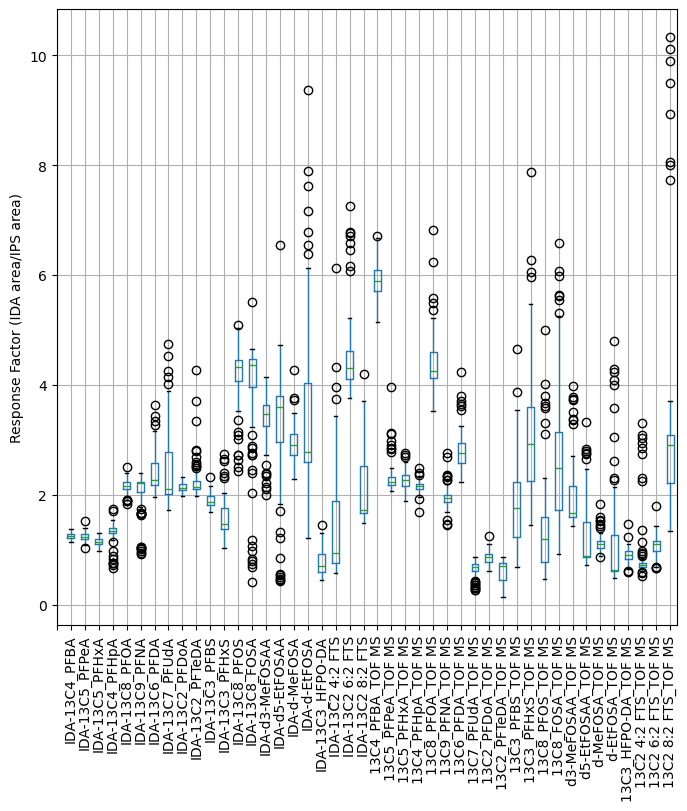

In [23]:
if recovery_rate_type == 'eis':    
    # extract relavant columns from calibration data
    reference_data_eis = calculate_eis_nis_ratio(
        data=calibration_data, column_name='Response Factor Mean', eis_identifiers=eis_compounds_msms + eis_compounds_hrms
    )

    # create data frame with this response factor calculation (from scratch), the standard deviation and the original values evaluated by Sciex,
    response_factor = reference_data_eis.groupby('Component Name', as_index=False)['Response Factor Mean'].mean()
    response_factor['Response Factor Std'] = reference_data_eis.groupby('Component Name')['Response Factor Mean'].std().to_list()
    response_factor.index = response_factor['Component Name']
    response_factor = response_factor.drop(columns=['Component Name']).reindex(eis_compounds_msms + eis_compounds_hrms)

    # create and save response factor box plots
    image_path = os.path.join(plot_directory, 'response_factors.png')
    fig, ax = plt.subplots(figsize=(8, 8))

    response_factor_grouped = reference_data_eis.groupby('Component Name', sort=False)
    response_factor_grouped.boxplot(column='Response Factor Mean', ax=ax, subplots=False)

    ax.set_xticks(range(len(response_factor_grouped) + 1))
    ax.set_xticklabels([''] + eis_compounds_msms + eis_compounds_hrms, rotation=90)
    fig.suptitle('')
    ax.set_title('')
    plt.ylabel('Response Factor (IDA area/IPS area)')
    plt.xticks(rotation=90)
    plt.savefig(image_path, bbox_inches='tight')
    plt.show()

In [24]:
if recovery_rate_type == 'eis':     
    # Select ida rows from quantification data and calculate ida ips ratio
    # function is defined in previous block
    quantification_ida = calculate_eis_nis_ratio(
        data=sample_data, column_name="IDA-IPS Ratio", eis_identifiers=eis_compounds_msms + eis_compounds_hrms
        )

    # initialize empty list for recovery table
    recovery_table: list[dict] = []
    # loop over eis
    for eis_selected in quantification_ida['Component Name'].unique():
        # get mean response factor for eis
        response_factor_mean = response_factor.loc[eis_selected, 'Response Factor Mean']
        # loop over sample indices
        for sample_index in quantification_ida['Sample Index'].unique():
            # find relevant row with sample index and eis
            selected_sample_ida = quantification_ida.loc[(
                (quantification_ida['Sample Index'] == sample_index) & 
                (quantification_ida['Component Name'] == eis_selected)
            ), :]
            # print error if no data is available, set corresponding recovery rate to np.nan
            if len(selected_sample_ida.index) == 0:
                print(f'Component {eis_selected} is not available for sample {sample_index}')
                ida_ips_ratio_mean = np.nan
            # get ida-ips ratio
            else:
                ida_ips_ratio_mean = selected_sample_ida['IDA-IPS Ratio'].values[0]
            # calculate recovery rate
            recovery_rate = 100 * ida_ips_ratio_mean / response_factor_mean
            # get sample number
            sample_number = sample_index_mapper_sample_number[sample_index]
            # append to list, which is converted to dataframe later
            recovery_table.append({
                'Sample Number': int(sample_number), 'Sample Index': sample_index, 'Component Name': eis_selected, 'IDA-IPS Ratio': ida_ips_ratio_mean,
                'Response Factor Mean': response_factor_mean, 'Recovery Rate': recovery_rate,
                })
    # convert list of dictionaries to dataframe    
    recovery_table = pd.DataFrame(recovery_table)

    # check if recovery rate is within indicated limit for each ida and save check results to 'Poor Recovery' column
    recovery_table = flag_poor_recovery(
        data=recovery_table, checked_column_name='Recovery Rate', new_column_name='Poor Recovery',
        columns_sorted=eis_compounds_msms + eis_compounds_hrms, hrms_identifier=hrms_identifier, eis_identifier=eis_identifier,
        )

    # take sample data and append Recovery Rate to each row
    sample_data[['Recovery Rate', 'RR']] = np.nan
    for row_index in sample_data.index:
        sample_index = sample_data.loc[row_index, 'Sample Index']
        eis_channel_name = sample_data.loc[row_index, 'IS Name']

        rr_row = recovery_table[(
            (recovery_table['Component Name'] == eis_channel_name) &
            (recovery_table['Sample Index'] == sample_index)
        )]

        if eis_channel_name in recovery_table['Component Name'].tolist():
            sample_data.loc[row_index, 'Recovery Rate'] = \
                rr_row.loc[:, 'Recovery Rate'].values[0]
            sample_data.loc[row_index, 'RR'] = \
                rr_row.loc[:, 'Poor Recovery'].values[0]

    for (compound_list, channel) in zip(
        [pfas_compounds_msms, pfas_compounds_hrms], ["MSMS", "HRMS"]
        ):

        recovery_data_pivot = sample_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='Recovery Rate', dropna=False,
        )[compound_list]
        recovery_data_pivot_flag = sample_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='RR', dropna=False,
        )[compound_list]
        concentration_data_pivot_flag = concentration_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='BDL', dropna=False,
        )[compound_list]
        retention_time_is_flag = retention_time_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='RTD', dropna=False,
        )[compound_list]
   
        # Write recovery rate to excel file
        with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
            recovery_data_pivot.to_excel(writer, sheet_name=f'{channel} Recovery Rate')
        reindex_in_excel(filename=processed_filepath_xlsx, sheetname=f'{channel} Recovery Rate')

        color_fields(filepath=processed_filepath_xlsx, sheetname=f'{channel} Recovery Rate',
                     rtd=retention_time_is_flag.fillna(value=False), bdl=concentration_data_pivot_flag.fillna(value=False),
                     rr=recovery_data_pivot_flag.fillna(value=False))

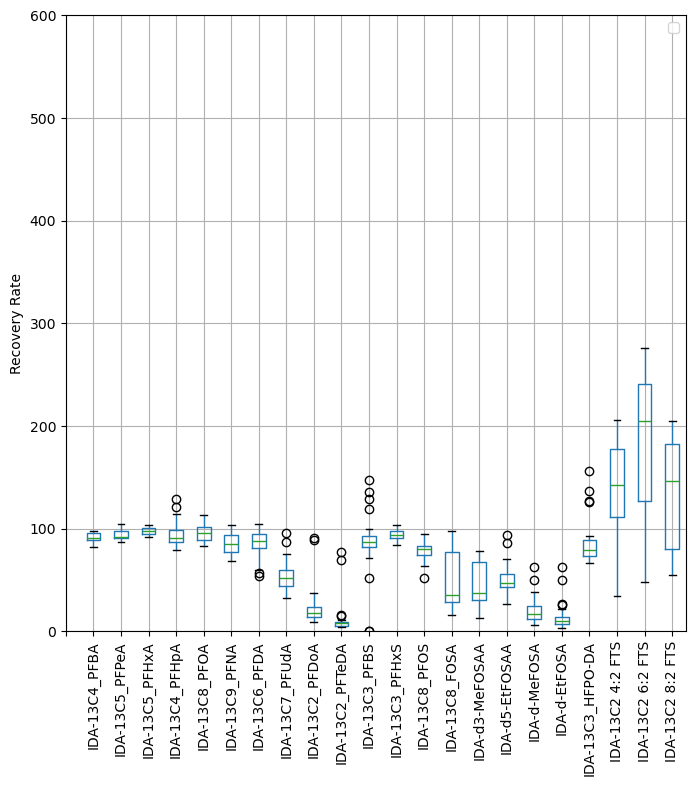

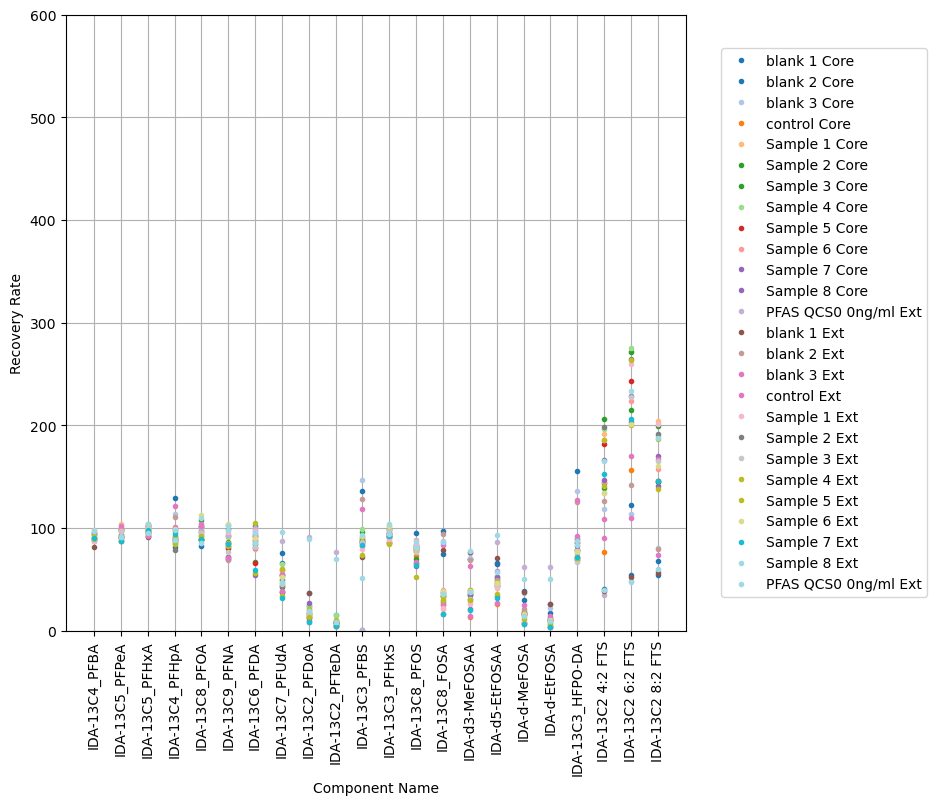

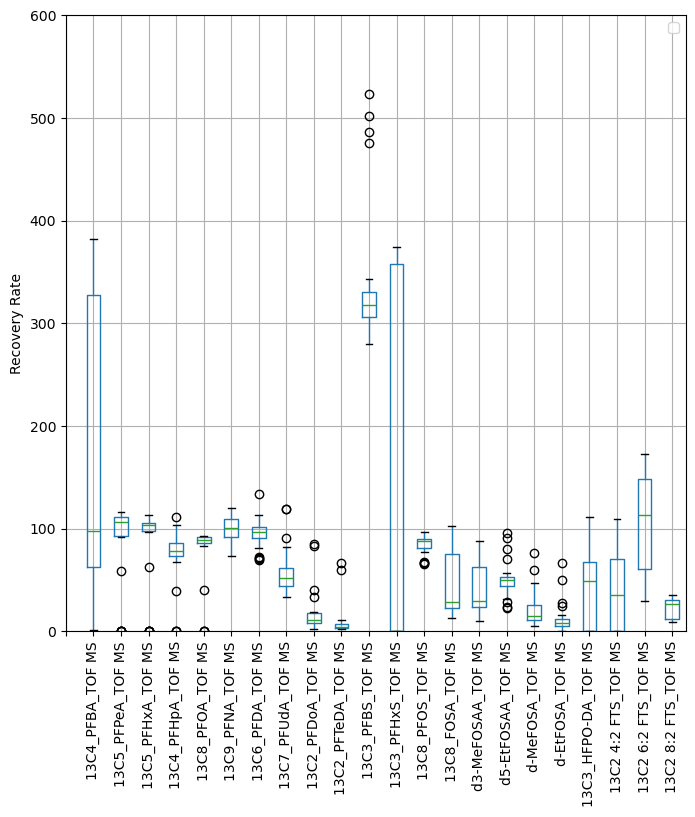

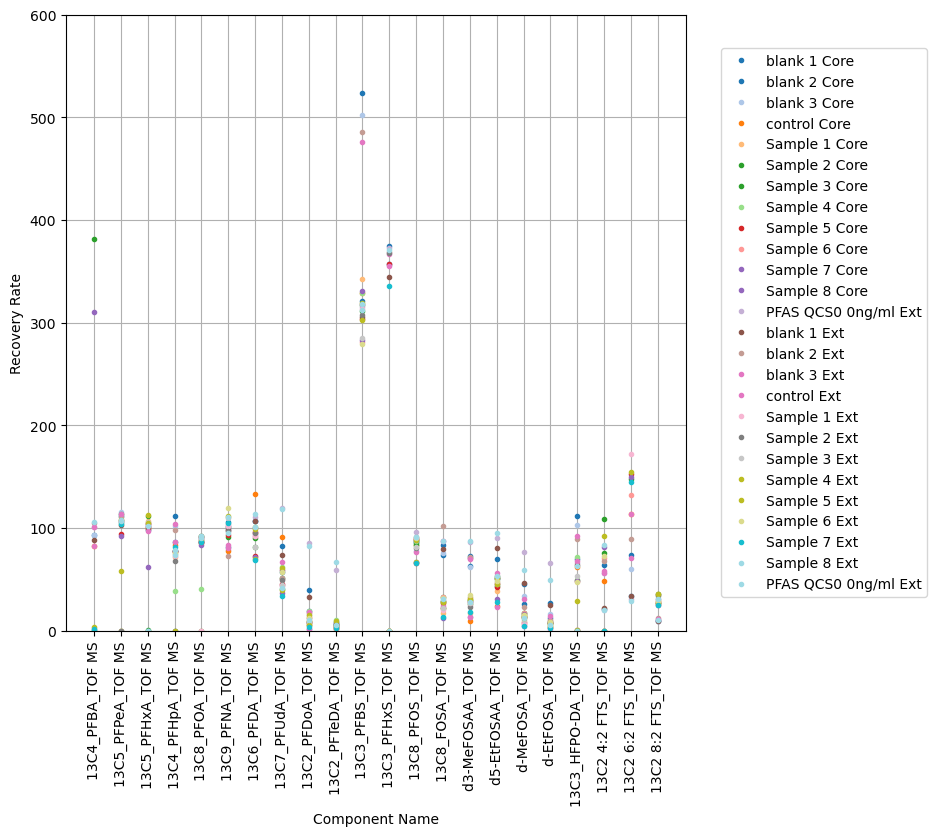

In [25]:
if recovery_rate_type == 'eis':     
    for (compound_list, channel) in zip(
        [eis_compounds_msms, eis_compounds_hrms], ["MSMS", "HRMS"]
        ):
        # Box plot for recovery rates
        image_path = os.path.join(plot_directory, f'{channel}_recovery_rates_box.png')
        fig, ax = plt.subplots(figsize=(8, 8))
        recovery_grouped = recovery_table.loc[recovery_table['Component Name'].isin(compound_list),:].groupby('Component Name', sort=False)
        recovery_grouped.boxplot(column='Recovery Rate', ax=ax, subplots=False)
        ax.set_ylim([0, recovery_limit_plot])
        ax.set_xticks(range(len(recovery_grouped) + 1))
        ax.set_xticklabels([''] + compound_list, rotation=90)
        fig.suptitle('')
        ax.set_title('')
        plt.ylabel('Recovery Rate')
        plt.xticks(rotation=90)
        plt.legend()
        plt.savefig(image_path, bbox_inches='tight')
        plt.show()

        # plot data as points for recovery rates:
        plot_data = recovery_table.loc[recovery_table['Component Name'].isin(compound_list),:].groupby('Sample Index')  # group data for plotting
        cmap = plt.cm.get_cmap('tab20', len(plot_data)) # initialize colours
        image_path = os.path.join(plot_directory, f'{channel}_recovery_rates.png')  # set path for figure

        fig, ax = plt.subplots(figsize=(8, 8))
        for indexed_compound_name, (title, group) in enumerate(plot_data):
            group.set_index(group['Component Name'], inplace=True)
            group.drop_duplicates(keep='first', inplace=True)
            group.plot(
                y='Recovery Rate', ax=ax, marker='.', linestyle='None', label=sample_index_mapper_sample_name_orig[title],
                grid=True, color = cmap(indexed_compound_name),
            )
        ax.set_ylim([0, recovery_limit_plot])
        fig.suptitle('')
        ax.set_xticks(range(len(group)))
        ax.set_xticklabels(group['Component Name'], rotation=90)
        ax.set_title('')
        plt.xticks(rotation=90)
        plt.ylabel('Recovery Rate')
        plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
        plt.savefig(image_path, bbox_inches='tight')
        plt.show()

        # save recovery rate plot to excel file
        workbook = load_workbook(processed_filepath_xlsx)
        plot_sheet = workbook.create_sheet(f'{channel} Recovery Rates Plots')

        img1 = Image(os.path.join(plot_directory, f'{channel}_recovery_rates_box.png'))
        img1.anchor = 'A1'
        plot_sheet.column_dimensions['A'].width = img1.width / 6
        plot_sheet.row_dimensions[1].height = img.height
        plot_sheet.add_image(img1)

        img2 = Image(os.path.join(plot_directory, f'{channel}_recovery_rates.png'))
        img2.anchor = 'B1'
        plot_sheet.column_dimensions['B'].width = img2.width / 6
        plot_sheet.add_image(img2)

        workbook.save(processed_filepath_xlsx)

    change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
        'MSMS Recovery Rate', 'HRMS Recovery Rate', 'MSMS Recovery Rates Plots', 'HRMS Recovery Rates Plots', 
        ], color='FFFF00')

# Quality Criterion 3 B: Internal standard response deviation
In case only extracted internal standards (EIS) are available: the standard response deviation is computed by comparing areas of EIS per ng spiked EIS in the samples with the average found in initial calibration (or continous calibration verification).


The thresholds for internal standard response deviation are provided in the input file recovery_thresholds.csv. Values below the lower or above the higher threshold are flaged with 'SRD'. Results are written to excel and plots are created in the second code block.

In [26]:
if recovery_rate_type == 'compound':

    # select relavant columns of sample data
    selected_columns = [
        'Sample Index', 'Sample Number', 'Sample Name', 'Component Name', 'Actual Concentration', 'Area',
        ]
    standard_response_deviation_data = sample_data[selected_columns]

    # introduce new column standard response deviation and SRD
    standard_response_deviation_data['Standard Response Deviation'] = np.nan

    # Extract NIS MSMS and HRMS data from calibration and sample data
    calibration_data_eis = calibration_data[calibration_data['Component Name'].isin(eis_compounds_msms + eis_compounds_hrms)]
    standard_response_deviation_data = \
        standard_response_deviation_data[standard_response_deviation_data['Component Name'].isin(eis_compounds_msms + eis_compounds_hrms)]
    
    calibration_data_eis['Area per ng'] = calibration_data_eis['Area'] / calibration_data_eis['Actual Concentration']
    standard_response_deviation_data['Area per ng'] = standard_response_deviation_data['Area'] / standard_response_deviation_data['Actual Concentration']

    # evaluate mean per component for MSMS and HRMS for calibration and sample data
    calibration_eis_averages = calibration_data_eis.groupby('Component Name')['Area per ng'].mean()

    # loop over standards and evaluate ratios in %
    for eis_compound in eis_compounds_msms + eis_compounds_hrms:
        standard_response_deviation_data.loc[standard_response_deviation_data['Component Name'] == eis_compound, 'Standard Response Deviation'] = \
            100 * standard_response_deviation_data.loc[standard_response_deviation_data['Component Name'] == eis_compound, 'Area per ng'] / calibration_eis_averages.loc[eis_compound]

    # check if standard response deviation is within indicated limit for each eis and save check results to 'SRD' column
    srd_table = flag_poor_recovery(
        data=standard_response_deviation_data, checked_column_name='Standard Response Deviation', new_column_name='SRD',
        columns_sorted=eis_compounds_msms + eis_compounds_hrms, hrms_identifier=hrms_identifier, eis_identifier=eis_identifier,
        )
        
    # take sample data and append Recovery Rate to each row
    sample_data[['Standard Response Deviation', 'SRD']] = np.nan
    for row_index in sample_data.index:
        sample_index = sample_data.loc[row_index, 'Sample Index']
        eis_channel_name = sample_data.loc[row_index, 'IS Name']

        srd_row = srd_table[(
            (srd_table['Component Name'] == eis_channel_name) &
            (srd_table['Sample Index'] == sample_index)
        )]

        if eis_channel_name in srd_table['Component Name'].tolist():
            sample_data.loc[row_index, 'Standard Response Deviation'] = \
                srd_row.loc[:, 'Standard Response Deviation'].values[0]
            sample_data.loc[row_index, 'SRD'] = \
                srd_row.loc[:, 'SRD'].values[0]
        
    for (compound_list, channel) in zip(
        [pfas_compounds_msms, pfas_compounds_hrms], ["MSMS", "HRMS"]
        ):

        concentration_data_pivot_flag = concentration_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='BDL', dropna=False,
        )[compound_list]
        retention_time_is_flag = retention_time_data.pivot_table(
            index=('Sample Number',), columns='Component Name', values='RTD', dropna=False,
        )[compound_list]
    
        srd_data_pivot = sample_data.pivot_table(
                index=('Sample Number',), columns='Component Name', values='Standard Response Deviation', dropna=False,
            )[compound_list]
        srd_data_pivot_flag = sample_data.pivot_table(
                index=('Sample Number',), columns='Component Name', values=f'SRD', dropna=False,
            )[compound_list]
        
        # Write recovery rate to excel file
        with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
            srd_data_pivot.to_excel(writer, sheet_name=f'{channel} Standard Response Dev.')
        reindex_in_excel(filename=processed_filepath_xlsx, sheetname=f'{channel} Standard Response Dev.')

        color_fields(filepath=processed_filepath_xlsx, sheetname=f'{channel} Standard Response Dev.',
                     rtd=retention_time_is_flag.fillna(value=False), bdl=concentration_data_pivot_flag.fillna(value=False),
                     rr=srd_data_pivot_flag.fillna(value=False))

In [27]:
if recovery_rate_type == 'compound':     
    # Box plot for standard response deviation
    image_path = os.path.join(plot_directory, 'standard_response_box.png')
    fig, ax = plt.subplots(figsize=(8, 8))
    srd_grouped = srd_table.loc[srd_table['Component Name'].isin(eis_compounds_msms + eis_compounds_hrms),:].groupby('Component Name', sort=False)
    srd_grouped.boxplot(column='Standard Response Deviation', ax=ax, subplots=False)
    ax.set_ylim([0, recovery_limit_plot])
    ax.set_xticks(range(len(srd_grouped) + 1))
    ax.set_xticklabels([''] + eis_compounds_msms + eis_compounds_hrms, rotation=90)
    fig.suptitle('')
    ax.set_title('')
    plt.ylabel('Standard Response Deviation')
    plt.xticks(rotation=90)
    plt.legend()
    plt.savefig(image_path, bbox_inches='tight')
    plt.show()

    # plot data as points for recovery rates:
    plot_data = srd_table.loc[srd_table['Component Name'].isin(eis_compounds_msms + eis_compounds_hrms),:].groupby('Sample Number')  # group data for plotting
    cmap = plt.cm.get_cmap('tab20', len(plot_data)) # initialize colours
    image_path = os.path.join(plot_directory, 'standard_response.png')  # set path for figure

    fig, ax = plt.subplots(figsize=(8, 8))
    for indexed_compound_name, (title, group) in enumerate(plot_data):
        group.set_index(group['Component Name'], inplace=True)
        group.drop_duplicates(keep='first', inplace=True)
        group.plot(
            y='Standard Response Deviation', ax=ax, marker='.', linestyle='None', label=sample_number_mapper_sample_name[title],
            grid=True, color = cmap(indexed_compound_name),
        )
    ax.set_ylim([0, recovery_limit_plot])
    fig.suptitle('')
    ax.set_xticks(range(len(group)))
    ax.set_xticklabels(group['Component Name'], rotation=90)
    ax.set_title('')
    plt.xticks(rotation=90)
    plt.ylabel('Standard Response Deviation')
    plt.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
    plt.savefig(image_path, bbox_inches='tight')
    plt.show()

    # save recovery rate plot to excel file
    workbook = load_workbook(processed_filepath_xlsx)
    plot_sheet = workbook.create_sheet(f'Standard Response Plots')

    img1 = Image(os.path.join(plot_directory, 'standard_response_box.png'))
    img1.anchor = 'A1'
    plot_sheet.column_dimensions['A'].width = img1.width / 6
    plot_sheet.row_dimensions[1].height = img1.height
    plot_sheet.add_image(img1)

    img2 = Image(os.path.join(plot_directory, 'standard_response.png'))
    img2.anchor = 'B1'
    plot_sheet.column_dimensions['B'].width = img2.width / 6
    plot_sheet.add_image(img2)

    workbook.save(processed_filepath_xlsx)

    change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
        'MSMS Standard Response Dev.', 'HRMS Standard Response Dev.', 'Standard Response Plots'
    ], color='FFFF00')

# Quality Criterion 4: Ion abundance ratios
The following three code blocks evaluate ion abundance ratio deviations.

The first code block provides a function to calculate the ratio of areas between HRMS channel and MSMS channel for each sample and each compound.

$IAR_{PFAS} = \frac{Area-HRMS_{PFAS}}{Area-MSMS_{PFAS}}$

The second code block evaluates the ion abundance ratios for the reference midpoint calibration data (either from continous calibration verification CCV or initial calibration), computes the average, writes the results to excel and plots the results.

The third code block evaluates ion abundance ratio deviations by comparing ion abundance ratios of sample data to the average ratios found in the calibration midpoint (CSM) to evaluate the percentage deviation:

$IAR~deviation_{sample, PFAS} = 100 \cdot (\frac{IAR_{sample, PFAS}}{mean(IAR_{CSM,PFAS})} - 1)$

In addition, ion abundance ratio deviations greater than the limit from the simulation parameters are flagged

In [28]:
# Assign HRMS channel to each MS MS channel and caluclate ion abundance ratio. 
# define funtion which calculates the ion abundance ratio
def calculate_ion_abundance_ratio(pfas_compounds_hrms: list[str], pfas_components_msms: list[str], data:pd.DataFrame) -> pd.DataFrame:
    """Calculate ion abundance ratio of a given data set.

    :param pfas_compounds_hrms: List of all PFAS compounds from HRMS channel in the right order.
    :type pfas_compounds_hrms: list[str]
    :param pfas_components_msms: List of all PFAS compounds having an MSMS channel in the right order.
    :type pfas_components_msms: list[str]
    :param data:  Entire data junk (including all rows and the following columns:
    Component Name, Sample Index, Sample Name, Area
    :type data: pd.DataFrame
    :return:  Data junk containing area of tof component and ion abundance ratio for msms channels as new column.
    :rtype: pd.DataFrame
    """
    # Initialize new columns and set them to NaN per default
    data['Ion Abundance Ratio'] = np.nan
    data['HRMS Area'] = np.nan

    # get index of msms component of exact same sample and tof component of exact same sample
    for sample_index in data['Sample Index'].unique():
        selected_sample_data = data.loc[data['Sample Index'] == sample_index, :]
        for (msms_component, hrms_component) in zip(pfas_components_msms, pfas_compounds_hrms):
            msms_row_index = selected_sample_data.loc[selected_sample_data['Component Name'] == msms_component, :].index.to_list()
            hrms_row_index = selected_sample_data.loc[selected_sample_data['Component Name'] == hrms_component, :].index.to_list()

            # find right msms channel row in case two components are availeble (core vs. extended method)
            if len(msms_row_index) == 0:
                print(f'The compound {msms_component} is not available for sample with number {int(sample_index)}.')
                msms_area = np.nan
            elif len(msms_row_index) == 1:
                msms_area = data.loc[msms_row_index[0], 'Area']
            else:
                raise ImportError(
                    f"There are multiple compounds {msms_component} available for sample with number: {sample_index}"
                )

            # find right tof channel row in case two components are availeble (core vs. extended method)
            if len(hrms_row_index) == 0:
                print(f'The compound {hrms_component} is not available for sample with number {int(sample_index)}.')
                hrms_area = np.nan
            elif len(hrms_row_index) == 1:
                hrms_area = data.loc[hrms_row_index[0], 'Area']
            else:
                raise ImportError(
                    f"There are multiple compounds {hrms_component} available for sample with index: {sample_index}"
                )
    
            # calculate IAR if both msms channel and tof ms channel are available
            if (np.isnan(msms_area) and not np.isnan(hrms_area)) or (not np.isnan(msms_area) and np.isnan(hrms_area)):
                if len(msms_row_index) > 0:
                    data.loc[msms_row_index[0], 'Ion Abundance Ratio'] = np.inf
                if len(hrms_row_index) > 0:
                    data.loc[hrms_row_index[0], 'Ion Abundance Ratio'] = np.inf

            elif not (np.isnan(msms_area) or np.isnan(hrms_area)):
                # set values HRMS Area, and Ion Abundance Ratio for both HRMS and MSMS channel.
                data.loc[msms_row_index[0], 'HRMS Area'] = hrms_area
                data.loc[msms_row_index[0], 'Ion Abundance Ratio'] = hrms_area / msms_area
                data.loc[hrms_row_index[0], 'Ion Abundance Ratio'] = hrms_area / msms_area
    return data

The compound PFPrA is not available for sample with number 26.
The compound PFPrA_TOF MS is not available for sample with number 26.
The compound 3:3 FTCA is not available for sample with number 26.
The compound 3:3 FTCA_TOF MS is not available for sample with number 26.
The compound 5:3 FTCA is not available for sample with number 26.
The compound 5:3 FTCA_TOF MS is not available for sample with number 26.
The compound 7:3 FTCA is not available for sample with number 26.
The compound 7:3 FTCA_TOF MS is not available for sample with number 26.
The compound FOEA is not available for sample with number 26.
The compound FOEA_TOF MS is not available for sample with number 26.
The compound PFPrS is not available for sample with number 26.
The compound PFPrS_TOF MS is not available for sample with number 26.
The compound MeFBSA is not available for sample with number 26.
The compound MeFBSA_TOF MS is not available for sample with number 26.
The compound N-EtFBSA-M is not available for sample

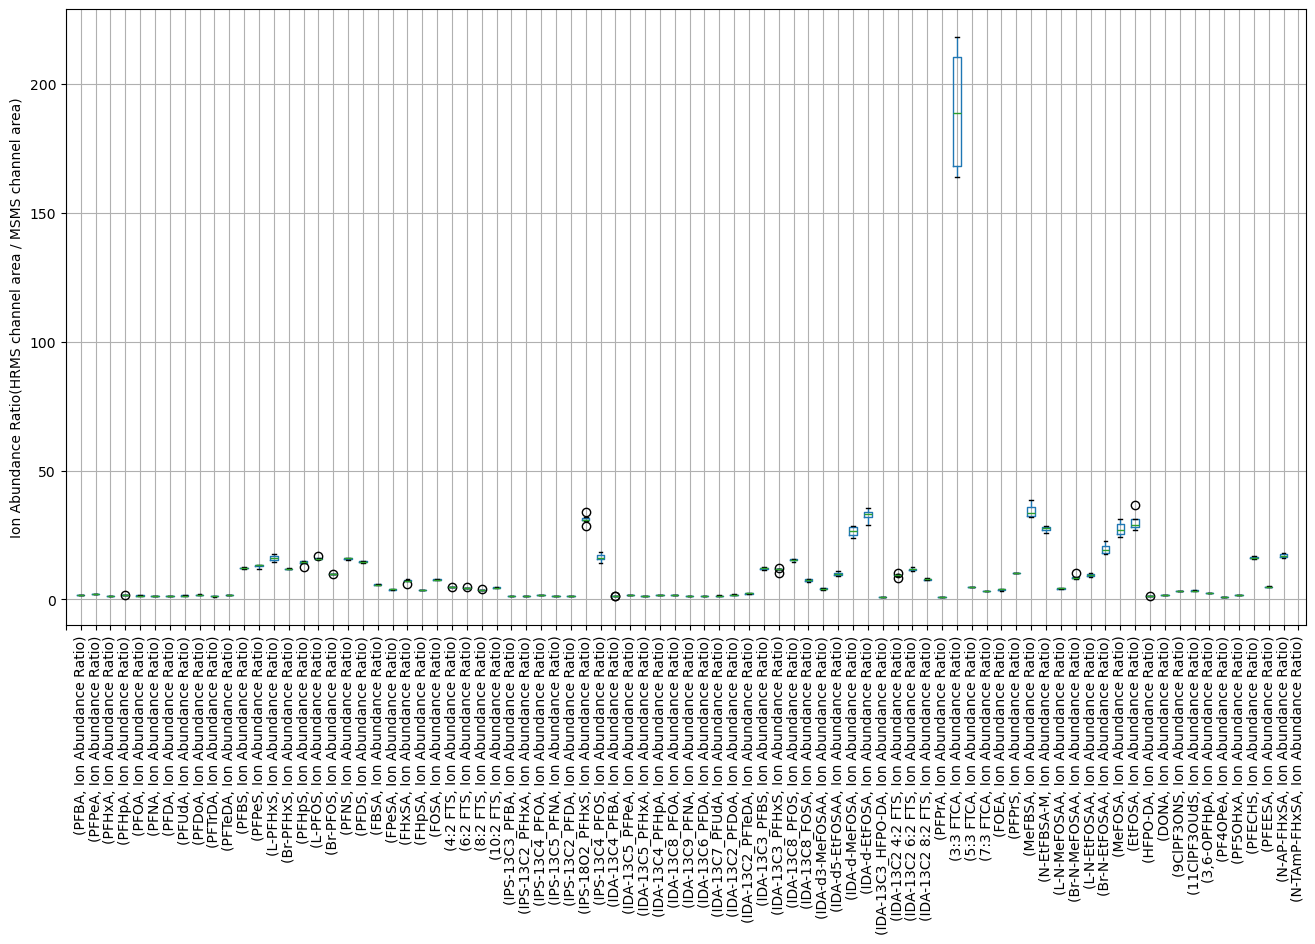

In [29]:
# select relavant columns of calibration midpoint data
selected_columns = [
    'Sample Index', 'Sample Name', 'Component Name', 'Area',
    ]
mass_channel_area_calibration_midpoint = calibration_reference_data[selected_columns]

# calculate ion abundance ratios and drop tof channel rows afterwards
ion_abundance_ratio_calibration_midpoint = calculate_ion_abundance_ratio(
    pfas_components_msms=compounds['MSMS Compound Name'].tolist() + standards['MSMS Standard Name'].to_list(),
    pfas_compounds_hrms=compounds['HRMS Compound Name'].tolist() + standards['HRMS Standard Name'].to_list(),
    data=mass_channel_area_calibration_midpoint
)

# group ion abundance ratios in calibration midpoint by component
ion_abundance_ratio_calibration_grouped_msms = ion_abundance_ratio_calibration_midpoint.loc[
    ~ion_abundance_ratio_calibration_midpoint['Component Name'].str.endswith(hrms_identifier), ['Component Name', 'Ion Abundance Ratio']
].groupby(
    'Component Name', as_index=True, sort=False
)

# evaluate mean of groups - ion abundance ratio per compound in calibration midpoint
ion_abundance_ratio_calibration_midpoint_mean = ion_abundance_ratio_calibration_midpoint[['Component Name', 'Ion Abundance Ratio']].groupby(
    'Component Name', as_index=True, sort=False
    ).mean()

# create and save response factor box plots
image_path = os.path.join(plot_directory, 'midpoint_ion_abundance_ratio.png')
fig, ax = plt.subplots(figsize=(16, 8))
ion_abundance_ratio_calibration_grouped_msms.boxplot(column='Ion Abundance Ratio', ax=ax, subplots=False)

ax.set_xticks(range(len(ion_abundance_ratio_calibration_grouped_msms) + 1))
fig.suptitle('')
ax.set_title('')
plt.ylabel('Ion Abundance Ratio(HRMS channel area / MSMS channel area)')
plt.xticks(rotation=90)
plt.savefig(image_path, bbox_inches='tight')
plt.show()

In [30]:
# initialize new ion abundance ratio data frame and select columns
ion_abundance_ratio_data = sample_data[selected_columns + ['Sample Number']]

# calculate ion abundance ratio for all compounds and standards and delete rows from HRMS channel afterwards
ion_abundance_ratio_data = calculate_ion_abundance_ratio(
    pfas_components_msms=compounds['MSMS Compound Name'].tolist(),
    pfas_compounds_hrms=compounds['HRMS Compound Name'].tolist(),
    data=ion_abundance_ratio_data
)

# Initialize new Ion Abundance Ratio Deviation column and set to False per default.
ion_abundance_ratio_data['IARD'] = np.nan

# loop over compounds
for compound in pfas_compounds_msms + pfas_compounds_hrms:
    # get ion abundance ratio of reference midpoint
    reference_ion_abundance_ratio_calibration_midpoint = ion_abundance_ratio_calibration_midpoint_mean.loc[compound, 'Ion Abundance Ratio']
    # get accepted ion abundance ratio from compound name
    if compound in rtd_and_iar_thresholds_channel_selection.index.tolist():
        iard_threshold = rtd_iard_channel_dict['accepted ion abundance ratio deviation [%]'][compound]
    elif compound.endswith(hrms_identifier):  # HRMS channel
        if compound in eis_compounds_hrms:  # construct MSMS name from EIS name if EIS
            iard_threshold = rtd_iard_channel_dict['accepted ion abundance ratio deviation [%]'][eis_identifier + '-' + compound[:(-1) * hrms_identifier_string_number]]
        elif compound in eis_compounds_hrms:  # construct MSMS name from NIS name if NIS
            iard_threshold = rtd_iard_channel_dict['accepted ion abundance ratio deviation [%]'][nis_identifier + '-' + compound[:(-1) * hrms_identifier_string_number]]
        else:
            # in rare cases tof standard does not exsist search for standard names in msms lists
            if compound[:(-1) * hrms_identifier_string_number] in rtd_and_iar_thresholds_channel_selection.index.tolist():
                iard_threshold = rtd_iard_channel_dict['accepted ion abundance ratio deviation [%]'][compound[:(-1) * hrms_identifier_string_number]]
            else:  # construct MSMS name from compound if in compounds
                iard_threshold = np.nan
    else:
        iard_threshold = np.nan

    # loop over sample indices
    for sample_index in ion_abundance_ratio_data['Sample Index'].unique():
        # get index from sample and compound
        selected_index = ion_abundance_ratio_data[(
            (ion_abundance_ratio_data['Sample Index'] == int(sample_index)) & 
            (ion_abundance_ratio_data['Component Name'] == compound)
        )].index.to_list()

        if len(selected_index) == 0:
            continue
        elif len(selected_index) == 1:
            # calculate ion abundance ratio deviation
            ion_abundance_ratio_deviation = 100 * (ion_abundance_ratio_data.loc[int(selected_index[0]), 'Ion Abundance Ratio'] / reference_ion_abundance_ratio_calibration_midpoint - 1)
            # check threshold
            iard = abs(ion_abundance_ratio_deviation) > iard_threshold
            # calculate ion abundance ratio deviation
            ion_abundance_ratio_data.loc[int(selected_index[0]), ['Ion Abundance Ratio Deviation [%]', 'IARD']] = \
                [ion_abundance_ratio_deviation, iard]
        else:
            raise NameError(
                f"There are multiple compounds {compound} available for sample with index: {sample_index}"
                )

# Introduce new column where everything above or below threshold is flagged
nan_flag = ion_abundance_ratio_data['Ion Abundance Ratio Deviation [%]'].isnull()
ion_abundance_ratio_data.loc[nan_flag, 'IARD'] = np.nan

# Put channel ratio in pivot table
ion_abundance_ratio_table = ion_abundance_ratio_data.pivot_table(
    index=('Sample Number'), columns='Component Name', values='Ion Abundance Ratio Deviation [%]', dropna=False,
)[pfas_compounds_msms]
# construct iar flag table accordingly
ion_abundance_ratio_flag = ion_abundance_ratio_data.pivot_table(
    index=('Sample Number'), columns='Component Name', values=f'IARD', dropna=False,
)[pfas_compounds_msms]

# put mdl flag in pivot table
concentration_data_pivot_flag = concentration_data.pivot_table(
        index=('Sample Number'), columns='Component Name', values='BDL', dropna=False,
    )[pfas_compounds_msms]
# put retention time flag in pivot table
retention_time_is_flag = retention_time_data.pivot_table(
        index=('Sample Number'), columns='Component Name', values='RTD', dropna=False,
    )[pfas_compounds_msms]

# construct recovery flag table accordingly
if recovery_rate_type == 'eis':
    recovery_rate_flag = sample_data.pivot_table(
            index=('Sample Number'), columns='Component Name', values='RR', dropna=False,
    )[pfas_compounds_msms]
else:
    recovery_rate_flag = sample_data.pivot_table(
            index=('Sample Number'), columns='Component Name', values='SRD', dropna=False,
    )[pfas_compounds_msms]

# Write to excel file
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
    ion_abundance_ratio_table.to_excel(writer, sheet_name='IAR Deviation in %')

# color values based on flags
color_fields(
    filepath=processed_filepath_xlsx, sheetname='IAR Deviation in %',
    rtd=retention_time_is_flag.fillna(value=False), bdl=concentration_data_pivot_flag.fillna(value=False),
    rr=recovery_rate_flag.fillna(value=False), iard=ion_abundance_ratio_flag.fillna(value=False))

reindex_in_excel(filename=processed_filepath_xlsx, sheetname='IAR Deviation in %')

change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
        'IAR Deviation in %'
    ], color='7F00FF')

The compound PFPrA is not available for sample with number 46.
The compound PFPrA_TOF MS is not available for sample with number 46.
The compound 3:3 FTCA is not available for sample with number 46.
The compound 3:3 FTCA_TOF MS is not available for sample with number 46.
The compound 5:3 FTCA is not available for sample with number 46.
The compound 5:3 FTCA_TOF MS is not available for sample with number 46.
The compound 7:3 FTCA is not available for sample with number 46.
The compound 7:3 FTCA_TOF MS is not available for sample with number 46.
The compound FOEA is not available for sample with number 46.
The compound FOEA_TOF MS is not available for sample with number 46.
The compound PFPrS is not available for sample with number 46.
The compound PFPrS_TOF MS is not available for sample with number 46.
The compound MeFBSA is not available for sample with number 46.
The compound MeFBSA_TOF MS is not available for sample with number 46.
The compound N-EtFBSA-M is not available for sample

# Ouputs and data merging

In the following code block all relevant data and parameters are combined in one common dataframe quantification_pfas_default, which has one row for each (MSMS) PFAS compound in each sample: \
(1) The recovery rate is assigned to each (MSMS) PFAS compound. Each PFAS compound has a corresponding IDA - the recovery rate is deduced from the recovery rate of the corresponding IDA. The assignment works for each sample by using the 'IS Name' column which provides information on which IDA standard is associated to which PFAS. In adddition, a boolean column is appended, indicating if the recovery rates are in the allowed limits.\
(2) detection limits are appended to the table as well as a boolean column indicating if the detected values are below the threshold. \
(3) basic information about the sample are included in the final data frame. \
(4) ion abundance ratios deviations are included, as well as a boolean column inidcating if the QAQC criteria are met.
(5) retention time differences are included in the final table with respect to internal standards and the same compounds in the calibration midpoint. For both options a boolean column inidcating if the QAQC criteria are met is appended.

In [31]:
# Initialize data frame for following assignments, select only needed columns and use reasonable naming.
selected_columns = [
        'Sample Name', 'Sample Number', 'Sample ID', 'Acquisition Date & Time', 'Component Name',
        'Calculated Concentration', 'Area', 'IS Name',
        ]
if recovery_rate_type == 'eis':
    quantification_pfas_default = sample_data[selected_columns + ['RR']]
else:
    quantification_pfas_default = sample_data[selected_columns + ['SRD']]

# select only target compounds (get rid of internal standards)
quantification_pfas_default = quantification_pfas_default[
    quantification_pfas_default['Component Name'].isin(pfas_compounds_selected)
    ]
quantification_pfas_default.rename(columns={'IS Name': 'EIS Name'}, inplace=True)

# initialize new columns
if standard_concentration == 'spiked_per_sample':
    quantification_pfas_default[[
            'RTD', 'Sample Quantity', 'Sample Unit', 'IDL [ng/sample]', 'MDL [ng/sample]', 'BDL', 'IAR Deviation', 'IARD', 'flag',
        ]] = np.nan
elif standard_concentration == 'spiked_per_ml_sample':
    quantification_pfas_default[[
            'RTD', 'Sample Quantity', 'Sample Unit', 'IDL [ng/mL]', 'MDL [ng/mL]', 'BDL', 'IAR Deviation', 'IARD', 'flag',
        ]] = np.nan

for row_index in quantification_pfas_default.index:
    sample_number = quantification_pfas_default.loc[row_index, 'Sample Number']
    sample_name = quantification_pfas_default.loc[row_index, 'Sample Name']
    eis_channel_name = quantification_pfas_default.loc[row_index, 'EIS Name']
    component_name = quantification_pfas_default.loc[row_index, 'Component Name']

    rt_row = retention_time_data[(
        (retention_time_data['Component Name'] == component_name) &
        (retention_time_data['Sample Number'] == sample_number)
    )]
    
    concentration_row = concentration_data[(
        (concentration_data['Component Name'] == component_name) &
        (concentration_data['Sample Number'] == sample_number)
    )]

    iar_row = ion_abundance_ratio_data[(
            (ion_abundance_ratio_data['Component Name'] == component_name) &
            (ion_abundance_ratio_data['Sample Number'] == sample_number)
    )]

    # assign Sample Quantity and Sample Unit
    quantification_pfas_default.loc[row_index, 'Sample Quantity'] = \
        sample_input_data.loc[sample_number, 'volume/weight/number of samples']
    quantification_pfas_default.loc[row_index, 'Sample Unit'] = \
        sample_input_data.loc[sample_number, 'unit (e.g. g/mL/sample)']
    quantification_pfas_default.loc[row_index, 'Dilution Factor'] = \
        sample_input_data.loc[sample_number, 'dilution factor']

    # assign RTD
    quantification_pfas_default.loc[row_index, 'RTD'] = rt_row.loc[:,'RTD'].values[0]

    # assign IDL, MDL and BDL
    if standard_concentration == 'spiked_per_sample':
        quantification_pfas_default.loc[row_index, ['IDL [ng/sample]', 'MDL [ng/sample]', 'BDL', 'Corrected Concentration', 'Significance [sigma]']] = concentration_row.loc[:,
            ['IDL', 'MDL', 'BDL', 'Corrected Concentration', 'Significance in sigma']].values.flatten().tolist()
    elif standard_concentration == 'spiked_per_ml_sample':
        quantification_pfas_default.loc[row_index, ['IDL [ng/mL]', 'MDL [ng/mL]', 'BDL', 'Corrected Concentration', 'Significance [sigma]']] = concentration_row.loc[:,
            ['IDL', 'MDL', 'BDL', 'Corrected Concentration', 'Significance in sigma']].values.flatten().tolist()

    quantification_pfas_default.loc[row_index, 'IAR Deviation'] = \
        iar_row.loc[:, 'Ion Abundance Ratio Deviation [%]'].values[0]
    quantification_pfas_default.loc[row_index, 'IARD'] = \
        iar_row.loc[:, f'IARD'].values[0]

# set flags accordingly
quantification_pfas_default.loc[quantification_pfas_default['IARD'].fillna(False), 'flag'] = 'IARD'
if recovery_rate_type == 'eis':
    quantification_pfas_default.loc[quantification_pfas_default['RR'].fillna(False), 'flag'] = 'RR'
else:
    quantification_pfas_default.loc[quantification_pfas_default['SRD'].fillna(False), 'flag'] = 'SRD'
quantification_pfas_default.loc[quantification_pfas_default['BDL'].fillna(False), 'flag'] = 'BDL'
quantification_pfas_default.loc[quantification_pfas_default['RTD'].fillna(False), 'flag'] = 'RTD'
quantification_pfas_default.loc[quantification_pfas_default['Calculated Concentration'] == 0, 'flag'] = 'ND'

# Outputs
The following code block writes final concentration table with all information to excel:
- It uses retention time difference between compound and related internal standard and indicates all values above the allowed difference with 'RTD'\
- It uses concentration values and indicates all values below detection limit with 'BDL' \
- It uses recovery rates and indicates all values below or above the indicated thresholds with 'RR'. \
- It uses ion abundance ratio deviations and indicates all values below the allowed deviation with 'IARD' \

In addition, concentration values are converted to ng\g or ng\l respectively.

Writes final long format table to csv

In [32]:
def flag_values_string(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Introduces new column to dataframe with concentrations as string and flag label when flagged.
    RTD...retention time difference
    BDL...below detection limit
    RR...recovery rate
    IARD...ion abundance ratio deviation

    :param data: data frame containing column 'flag',
    as well as the column you indicated.
    :type data: pd.DataFrame
    :param column: Colun name of data frame to be filtered or flagged.
    :type column: str
    :return: Data frame, where the column data is flagged.
    :rtype: pd.DataFrame
    """

    final_table = data[['Sample Name', 'Sample Number', 'Component Name', column]]
    for (row_index, row) in data.iterrows():
        if np.isnan(row[column]):
            row_conc = 'NA'
        else:
            row_conc = str(round_to_n_sigfigs(row[column],4))
            if not pd.isnull(row['flag']):
                row_conc = row['flag']
            else:
                str(round_to_n_sigfigs(row[column],4))
        final_table.loc[row_index, column] = row_conc

    return final_table

def flag_values_na(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """Flags column values (most probably concentrations) which do not meet QAQC criteria,
    and replaces them with NaNs.

    :param data: data frame containing column 'flag',
    as well as the column you indicated.
    :type data: pd.DataFrame
    :param column: Column name of data frame to be filtered or flagged.
    :type column: str
    :return: Data frame, where the column data is flagged.
    :rtype: pd.DataFrame
    """
    final_table = data[['Sample Name', 'Sample Number', 'Component Name', column]]
    final_table[column] = final_table[column].apply(lambda x: round_to_n_sigfigs(x, 4))
    for (row_index, row) in data.iterrows():
        if not pd.isnull(row['flag']):
            final_table.loc[row_index, column] = np.nan
    # set zero concentations to NA as well
    final_table.loc[final_table[column] == 0, column] = np.nan
    return final_table

# Transform concentration to ng/g or ng/l, depending on your sample_unit
if standard_concentration == 'spiked_per_sample':
    quantification_pfas_default['Concentration in ng per Unit'] = quantification_pfas_default['Calculated Concentration'] \
        / quantification_pfas_default['Sample Quantity']
    quantification_pfas_default['Corrected Concentration'] = quantification_pfas_default['Corrected Concentration'] \
        / quantification_pfas_default['Sample Quantity']
elif standard_concentration == 'spiked_per_ml_sample':
    quantification_pfas_default['Concentration in ng per Unit'] = quantification_pfas_default['Calculated Concentration'] * 21  # 1/21 g tissue per mL sample
    quantification_pfas_default['Corrected Concentration'] = quantification_pfas_default['Corrected Concentration'] * 21  # 1/21 g tissue per mL sample

# Flag concentration values with channel ratio, recovery rates and detection threshold.
calculated_concentration_string = flag_values_string(data=quantification_pfas_default, column=f'Concentration in ng per Unit')
calculated_concentration_nan = flag_values_na(data=quantification_pfas_default, column=f'Concentration in ng per Unit')
corrected_concentration_string = flag_values_string(data=quantification_pfas_default, column=f'Corrected Concentration')
corrected_concentration_nan = flag_values_na(data=quantification_pfas_default, column=f'Corrected Concentration')
significance = flag_values_na(data=quantification_pfas_default, column=f'Significance [sigma]')

# Pivot concentration tables.
calculated_concentration_string = calculated_concentration_string.pivot(
    index=('Sample Number',), columns='Component Name', values=f'Concentration in ng per Unit',
)

calculated_concentration_nan = calculated_concentration_nan.pivot_table(
    index=('Sample Number',), columns='Component Name', values=f'Concentration in ng per Unit', dropna=False,
)

corrected_concentration_string = corrected_concentration_string.pivot(
    index='Sample Number', columns='Component Name', values=f'Corrected Concentration',
)

corrected_concentration_nan = corrected_concentration_nan.pivot_table(
    index=('Sample Number',), columns='Component Name', values=f'Corrected Concentration', dropna=False,
)

significance_nan = significance.pivot_table(
    index=('Sample Number',), columns='Component Name', values=f'Significance [sigma]', dropna=False,
)

# add unit to index of final concentration table
tuple_index = []
for sample_index in calculated_concentration_string.index:
    tuple_index.append((sample_number_mapper_sample_name[sample_index], 'ng/' + sample_number_mapper_sample_unit[sample_index]))

# get only selected pfas compounds (MSMS or HRMS, according to user input in sample input file)
calculated_concentration_string_channel = calculated_concentration_string[pfas_compounds_selected]
calculated_concentration_nan_channel= calculated_concentration_nan[pfas_compounds_selected]
corrected_concentration_nan_channel= corrected_concentration_nan[pfas_compounds_selected]
corrected_concentration_string_channel = corrected_concentration_string[pfas_compounds_selected]
significance_nan_channel= significance_nan[pfas_compounds_selected]

# reset index with added sample unit
calculated_concentration_string_channel.index = pd.Index(tuple_index)
calculated_concentration_nan_channel.index = pd.Index(tuple_index)
corrected_concentration_nan_channel.index = pd.Index(tuple_index)
corrected_concentration_string_channel.index = pd.Index(tuple_index)
significance_nan_channel.index = pd.Index(tuple_index)

# Write pivot tables to existing excel file
with pd.ExcelWriter(processed_filepath_xlsx, engine='openpyxl', mode='a') as writer:
    calculated_concentration_string_channel.to_excel(writer, sheet_name=f'Conc. (ng per Unit)')
    calculated_concentration_nan_channel.to_excel(writer, sheet_name=f'Num Conc. (ng per Unit)')
    corrected_concentration_string_channel.to_excel(writer, sheet_name=f'Conc. blank corrected')
    corrected_concentration_nan_channel.to_excel(writer, sheet_name=f'Num Conc. blank corrected')
    significance_nan_channel.to_excel(writer, sheet_name=f'Significance (sigma)')
change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
        'Conc. (ng per Unit)', 'Num Conc. (ng per Unit)',
    ], color='80FF00')
change_worksheet_color(filepath=processed_filepath_xlsx, sheetnames=[
    'Conc. blank corrected', 'Num Conc. blank corrected', 'Significance (sigma)'
    ], color='7FFFD4')

# Write long format data to csv
if standard_concentration == 'spiked_per_sample':
    quantification_pfas_default = quantification_pfas_default[[
        'Sample Name', 'Sample Number', 'Sample ID', 'Acquisition Date & Time','Component Name',
        'Calculated Concentration', 'Concentration in ng per Unit', 'Corrected Concentration', 'Significance [sigma]', 
        'Sample Unit', 'Sample Quantity', 'Dilution Factor', 'IDL [ng/sample]', 'MDL [ng/sample]', 'flag',
    ]]
    quantification_pfas_default.rename(columns={'Calculated Concentration': 'Concentration in ng/sample'}, inplace=True)
elif standard_concentration == 'spiked_per_ml_sample':
    quantification_pfas_default = quantification_pfas_default[[
        'Sample Name', 'Sample Number', 'Sample ID', 'Acquisition Date & Time','Component Name',
        'Calculated Concentration', 'Concentration in ng per Unit', 'Corrected Concentration', 'Significance [sigma]',
        'Sample Unit', 'Sample Quantity', 'Dilution Factor', 'IDL [ng/mL]', 'MDL [ng/mL]', 'flag',
    ]]
    quantification_pfas_default.rename(columns={'Calculated Concentration': 'Concentration in ng/mL'}, inplace=True)

quantification_pfas_default['Component Name'] = pd.Categorical(quantification_pfas_default['Component Name'], categories=pfas_compounds_selected, ordered=True)
quantification_pfas_default.sort_values(by=['Sample Number', 'Component Name'], inplace=True)
quantification_pfas_default.index = [i for i in range(len(quantification_pfas_default))]

# rename samples to publication names
quantification_pfas_default['Sample Name'] = [sample_number_mapper_sample_name[sample_number] for sample_number in quantification_pfas_default['Sample Number'].to_list()]
quantification_pfas_default.drop(columns=['Sample Number'], inplace=True)

quantification_pfas_default.to_csv(processed_filepath_csv)